# Billboard Hot 100 Data

### Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import requests
import time
import re
from difflib import SequenceMatcher

### read in (read and then filter ≥ 2005)

In [ ]:
# =========================
# 1. Load Billboard Hot 100 data
# =========================

df_billboard = pd.read_csv("hot100.csv")

# Convert chart dates into datetime
df_billboard["Date"] = pd.to_datetime(
    df_billboard["Date"],
    errors="coerce"
)

# Keep broad project time frame
df_billboard = df_billboard[
    df_billboard["Date"].dt.year >= 2005
].copy()

latest_date = df_billboard["Date"].max()

print("Oldest date:", df_billboard["Date"].min())
print("Newest date:", latest_date)
print("Weekly chart rows:", df_billboard.shape[0])


Oldest date: 2005-01-05 00:00:00
Newest date: 2026-05-20 00:00:00
Weekly chart rows: 111500


### Collapse + Build Features (chart life) UPDATED: 06/01/2026 11:15 PM

In [ ]:
# =========================
# 2. Collapse weekly chart rows into song-level lifecycle dataframe
# =========================

df = df_billboard.copy()

song_life = (
    df.sort_values("Date")
      .groupby(["Song", "Artist"], as_index=False)
      .agg(
          first_chart_date=("Date", "min"),
          last_chart_date=("Date", "max"),
          entry_rank=("Rank", "first"),
          peak_rank=("Rank", "min"),
          total_weeks=("Weeks in Charts", "max"),
          top10_weeks=("Rank", lambda x: (x <= 10).sum()),
          top40_weeks=("Rank", lambda x: (x <= 40).sum()),
          avg_rank=("Rank", "mean"),
          image_url=("Image URL", "first")
      )
)

# Find first date when each song hit its peak rank
peak_dates = (
    df.sort_values("Date")
      .loc[
          df.sort_values("Date")
            .groupby(["Song", "Artist"])["Rank"]
            .idxmin(),
          ["Song", "Artist", "Date"]
      ]
      .rename(columns={"Date": "peak_date"})
)

song_life = song_life.merge(
    peak_dates,
    on=["Song", "Artist"],
    how="left"
)

In [ ]:
# =========================
# 3. Add lifecycle timing metrics
# =========================

# Total lifecycle length on chart
song_life["lifespan_weeks"] = song_life["total_weeks"]

# Weeks from first chart appearance to peak rank
song_life["time_to_peak"] = (
    (song_life["peak_date"] - song_life["first_chart_date"]).dt.days / 7
)

# Entry year
song_life["entry_year"] = song_life["first_chart_date"].dt.year

# Era label
song_life["era"] = np.where(
    song_life["entry_year"] < 2016,
    "Pre TikTok",
    "Post TikTok"
)

# Higher value = better peak
song_life["peak_success"] = 101 - song_life["peak_rank"]

# Higher value = better average chart position
song_life["avg_success"] = 101 - song_life["avg_rank"]

# Weeks since last chart appearance
song_life["weeks_since_last_chart"] = (
    (latest_date - song_life["last_chart_date"]).dt.days / 7
)

# Flag songs whose chart run may still be incomplete near dataset endpoint
song_life["potentially_incomplete"] = (
    song_life["weeks_since_last_chart"] < 4
)

In [ ]:
# =========================
# 4. Basic sanity checks
# =========================

print("Song-level rows:", song_life.shape[0])

song_life[
    [
        "peak_rank",
        "peak_success",
        "total_weeks",
        "top10_weeks",
        "top40_weeks",
        "avg_rank",
        "time_to_peak",
        "entry_year"
    ]
].describe()

Song-level rows: 10505


,peak_rank,peak_success,total_weeks,top10_weeks,top40_weeks,avg_rank,time_to_peak,entry_year
count,10505.000000,10505.000000,10505.000000,10505.000000,10505.000000,10505.000000,10505.000000,10505.000000
mean,50.337363,50.662637,10.834745,1.061399,4.245597,65.043306,6.055307,2016.312613
std,29.269174,29.269174,11.691683,4.156856,9.235043,22.089007,23.873402,6.229256
min,1.000000,1.000000,1.000000,0.000000,0.000000,3.750000,0.000000,2005.000000
25%,25.000000,26.000000,1.000000,0.000000,0.000000,51.157895,0.000000,2011.000000
50%,52.000000,49.000000,6.000000,0.000000,0.000000,68.000000,0.000000,2017.000000
75%,75.000000,76.000000,20.000000,0.000000,2.000000,82.600000,8.000000,2022.000000
max,100.000000,100.000000,112.000000,80.000000,94.000000,100.000000,681.000000,2026.000000


In [ ]:
# Check incomplete songs
song_life["potentially_incomplete"].value_counts()

potentially_incomplete
False    10363
True       142
Name: count, dtype: int64

In [ ]:
# Preview final Billboard lifecycle dataframe
song_life.head()

,Song,Artist,first_chart_date,last_chart_date,entry_rank,peak_rank,total_weeks,top10_weeks,top40_weeks,avg_rank,image_url,peak_date,lifespan_weeks,time_to_peak,entry_year,era,peak_success,avg_success,weeks_since_last_chart,potentially_incomplete
0,"""1 Step Forward, 3 Steps Back""",Olivia Rodrigo,2021-06-02,2021-06-23,19,19,4,0,2,54.250000,https://charts-static.billboard.com/img/2019/1...,2021-06-02,4,0.0,2021,Post TikTok,82,46.750000,256.0,False
1,"""1, 2 Many""",Luke Combs & Brooks & Dunn,2019-09-25,2019-09-25,97,97,1,0,0,97.000000,https://charts-static.billboard.com/img/2015/0...,2019-09-25,1,0.0,2019,Post TikTok,4,4.000000,347.0,False
2,"""1, 2 Step""",Ciara Featuring Missy Elliott,2005-01-05,2005-07-20,2,2,39,12,24,19.448276,https://charts-static.billboard.com/img/2004/0...,2005-01-05,39,0.0,2005,Pre TikTok,99,81.551724,1087.0,False
3,"""1, 2, 3, 4""",Plain White T's,2009-02-04,2009-06-17,91,34,20,0,5,47.800000,https://charts-static.billboard.com/img/2005/1...,2009-05-20,20,15.0,2009,Pre TikTok,67,53.200000,883.0,False
4,"""10,000 Hours""",Dan + Shay & Justin Bieber,2019-10-16,2020-05-06,4,4,30,14,28,15.933333,https://charts-static.billboard.com/img/2019/1...,2019-10-16,30,0.0,2019,Post TikTok,97,85.066667,315.0,False


In [ ]:
song_life.to_csv(
    "billboard_song_lifecycle.csv",
    index=False
)

print("Saved billboard_song_lifecycle.csv")

Saved billboard_song_lifecycle.csv


### Separate COMPLETED from ALL

In [ ]:
song_life_all = song_life.copy()

song_life_completed = song_life[
    song_life["potentially_incomplete"] == False
].copy()

print("All songs:", song_life_all.shape)
print("Completed-only songs:", song_life_completed.shape)

All songs: (10505, 17)
Completed-only songs: (10363, 17)


## Chart Analysis

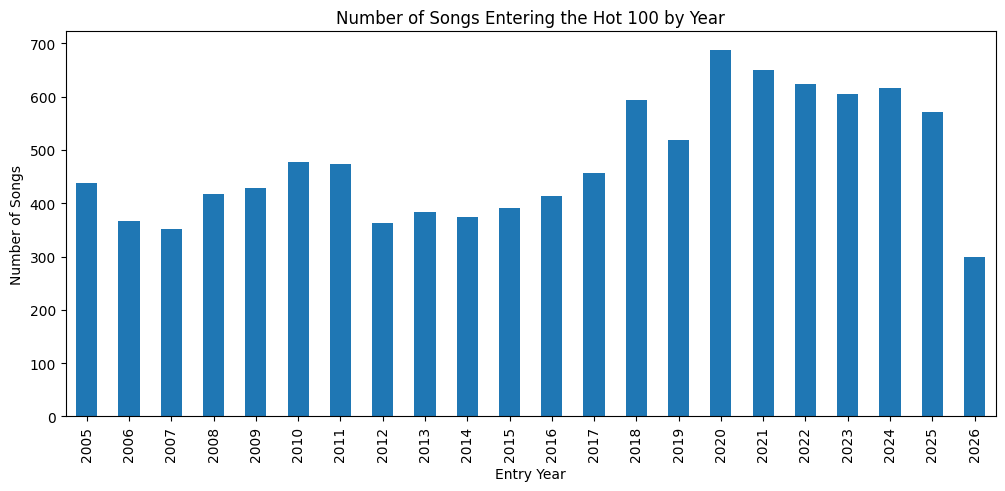

In [ ]:
# ================================
# SONG COUNTS BY YEAR
# ================================

song_life_all.groupby("entry_year").size().plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Number of Songs Entering the Hot 100 by Year")
plt.xlabel("Entry Year")
plt.ylabel("Number of Songs")
plt.show()

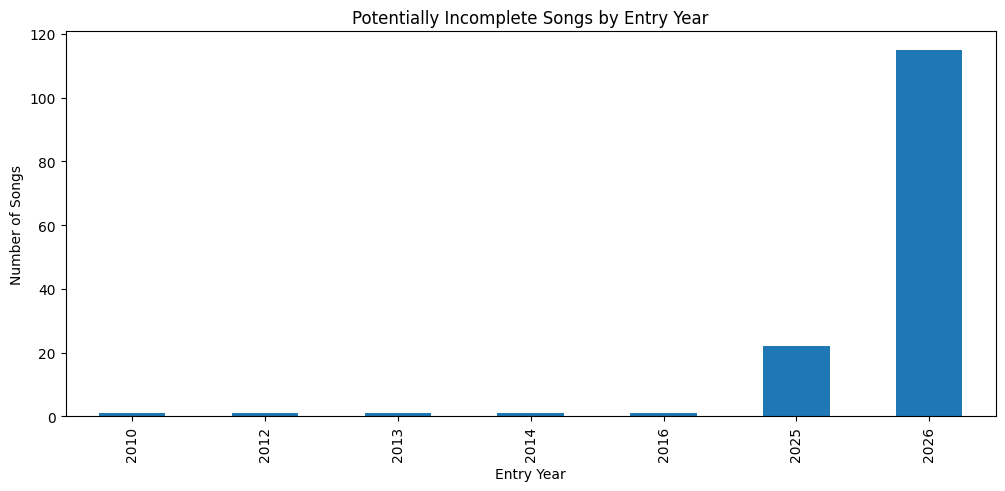

In [ ]:
# ================================
# INCOMPLETE SONGS CHECK
# ================================

excluded_by_year = (
    song_life[song_life["potentially_incomplete"]]
    .groupby("entry_year")
    .size()
)

excluded_by_year.plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Potentially Incomplete Songs by Entry Year")
plt.xlabel("Entry Year")
plt.ylabel("Number of Songs")
plt.show()

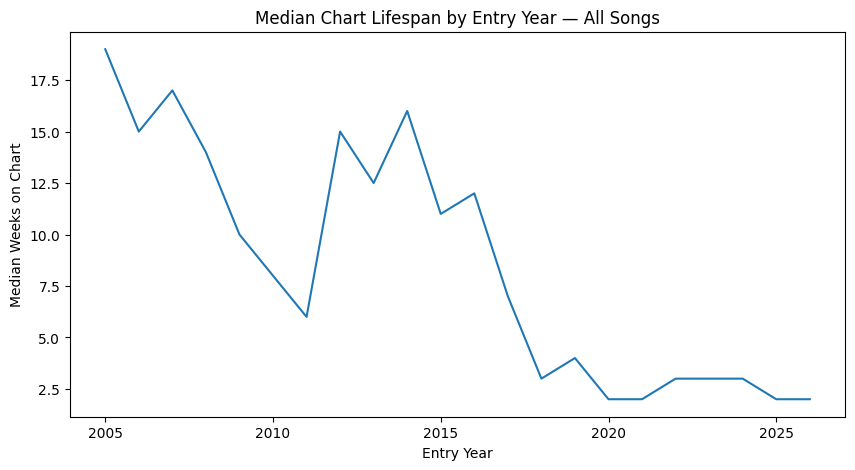

In [ ]:
# ================================
# MEDIAN LIFESPAN (ALL SONGS)
# ================================

median_all = (
    song_life_all
    .groupby("entry_year")["lifespan_weeks"]
    .median()
)

median_all.plot(figsize=(10, 5))

plt.title("Median Chart Lifespan by Entry Year — All Songs")
plt.xlabel("Entry Year")
plt.ylabel("Median Weeks on Chart")
plt.show()

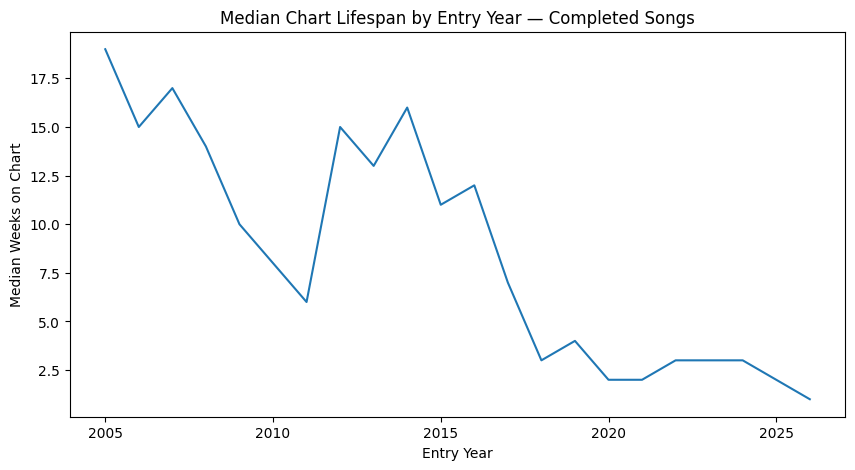

In [ ]:
# ================================
# MEDIAN LIFESPAN (COMPLETED ONLY)
# ================================

median_completed = (
    song_life_completed
    .groupby("entry_year")["lifespan_weeks"]
    .median()
)

median_completed.plot(figsize=(10, 5))

plt.title("Median Chart Lifespan by Entry Year — Completed Songs")
plt.xlabel("Entry Year")
plt.ylabel("Median Weeks on Chart")
plt.show()

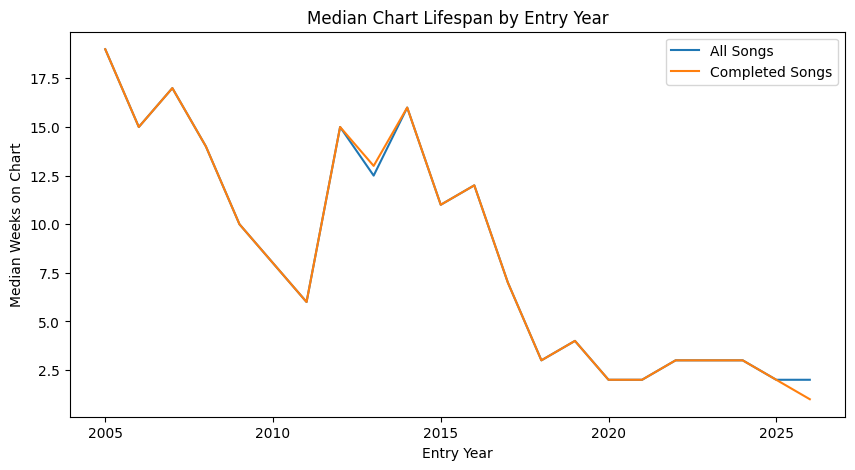

In [ ]:
# ================================
# ALL VS COMPLETED COMPARISON
# ================================

median_comparison = pd.DataFrame({
    "All Songs": median_all,
    "Completed Songs": median_completed
})

median_comparison.plot(figsize=(10, 5))

plt.title("Median Chart Lifespan by Entry Year")
plt.xlabel("Entry Year")
plt.ylabel("Median Weeks on Chart")
plt.show()

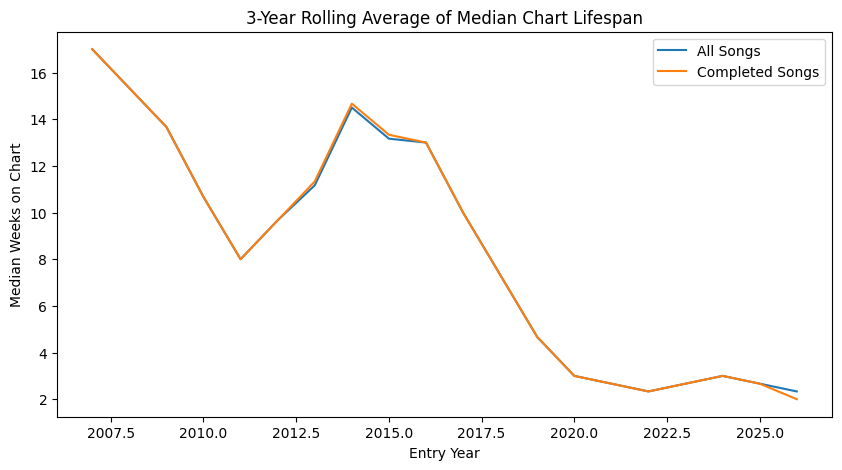

In [ ]:
# ================================
# SMOOTHED TREND
# ================================

median_comparison.rolling(3).mean().plot(figsize=(10, 5))

plt.title("3-Year Rolling Average of Median Chart Lifespan")
plt.xlabel("Entry Year")
plt.ylabel("Median Weeks on Chart")
plt.show()

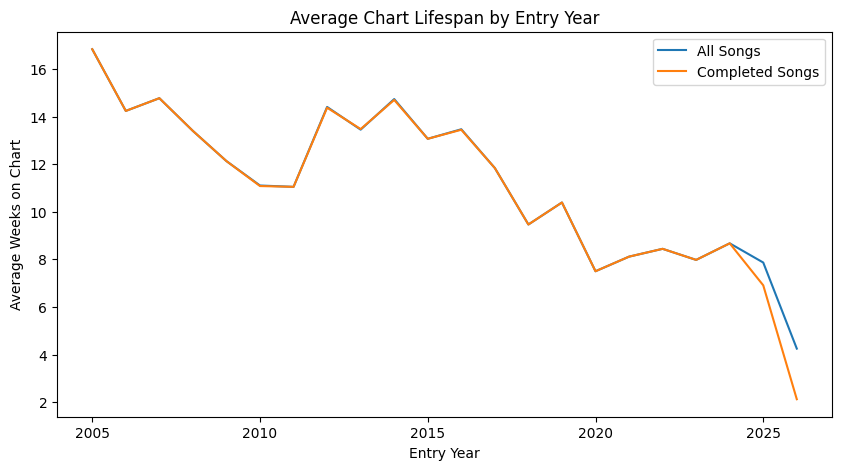

In [ ]:
# ================================
# MEAN LIFESPAN
# ================================

mean_all = (
    song_life_all
    .groupby("entry_year")["lifespan_weeks"]
    .mean()
)

mean_completed = (
    song_life_completed
    .groupby("entry_year")["lifespan_weeks"]
    .mean()
)

mean_comparison = pd.DataFrame({
    "All Songs": mean_all,
    "Completed Songs": mean_completed
})

mean_comparison.plot(figsize=(10, 5))

plt.title("Average Chart Lifespan by Entry Year")
plt.xlabel("Entry Year")
plt.ylabel("Average Weeks on Chart")
plt.show()

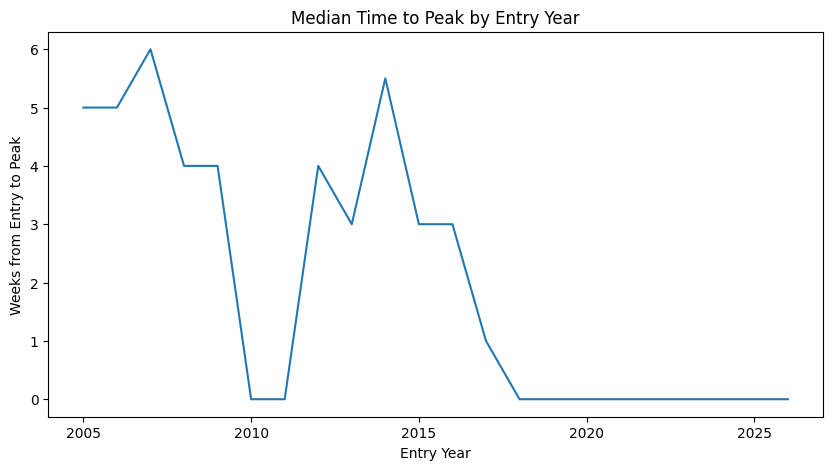

In [ ]:
# ================================
# TIME TO PEAK
# ================================

time_to_peak_by_year = (
    song_life_completed
    .groupby("entry_year")["time_to_peak"]
    .median()
)

time_to_peak_by_year.plot(figsize=(10, 5))

plt.title("Median Time to Peak by Entry Year")
plt.xlabel("Entry Year")
plt.ylabel("Weeks from Entry to Peak")
plt.show()

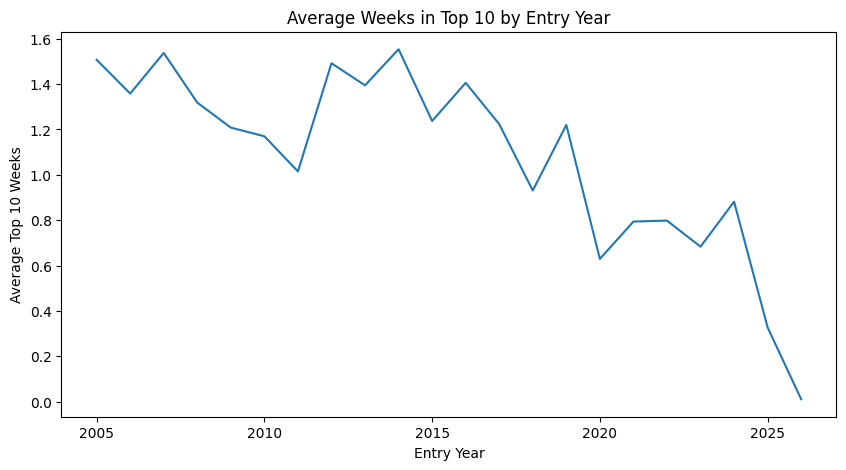

In [ ]:
# ================================
# TOP 10 PERSISTENCE
# ================================

# (uses mean because median gave '0' across the board since 
# less than half actually made Top 10)
top10_by_year = (
    song_life_completed
    .groupby("entry_year")["top10_weeks"]
    .mean()
)

top10_by_year.plot(figsize=(10, 5))

plt.title("Average Weeks in Top 10 by Entry Year")
plt.xlabel("Entry Year")
plt.ylabel("Average Top 10 Weeks")
plt.show()

In [ ]:
(song_life_completed["top10_weeks"] > 0).mean()

np.float64(0.11791952137411946)

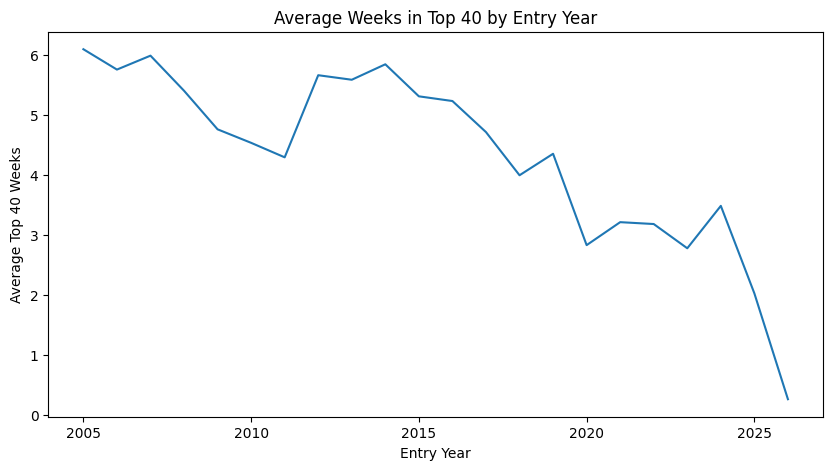

In [ ]:
# ================================
# TOP 40 PERSISTENCE
# ================================

# (uses mean because median gave '0' across the board since 
# less than half actually made Top 40)
top40_by_year = (
    song_life_completed
    .groupby("entry_year")["top40_weeks"]
    .mean()
)

top40_by_year.plot(figsize=(10, 5))

plt.title("Average Weeks in Top 40 by Entry Year")
plt.xlabel("Entry Year")
plt.ylabel("Average Top 40 Weeks")
plt.show()

(<Axes: xlabel='entry_year'>, <Axes: xlabel='entry_year'>)

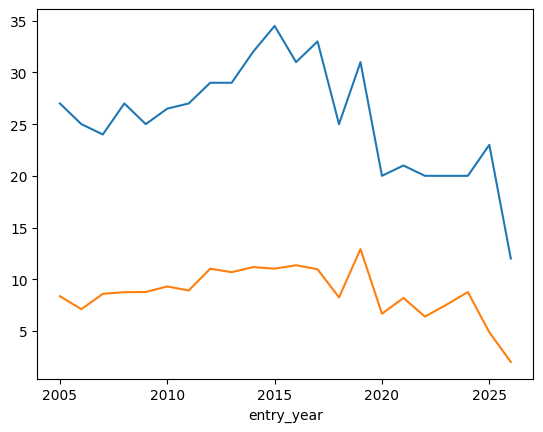

In [ ]:
# Isolating Top10 and Top40 hits
top10_hits = song_life_completed[
    song_life_completed["peak_rank"] <= 10
]

top40_hits = song_life_completed[
    song_life_completed["peak_rank"] <= 40
]

top10_hits.groupby("entry_year")["lifespan_weeks"].median().plot(), top10_hits.groupby("entry_year")["top10_weeks"].mean().plot()


/var/folders/bk/yngmbh1j5xdf2sk9yktp2cbr0000gn/T/ipykernel_19886/293373601.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["peak_rank"] <= 10).mean())


<Axes: xlabel='entry_year'>

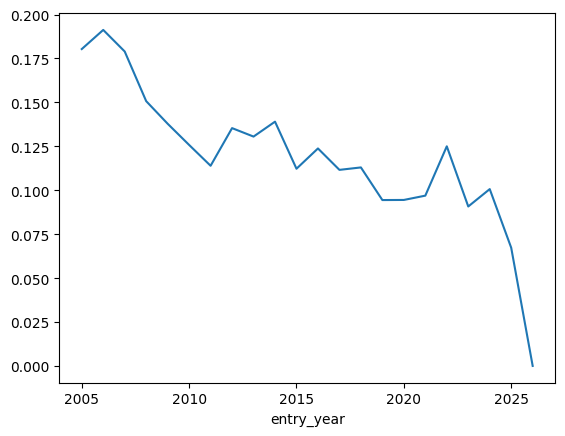

In [ ]:
# Percent of hits that reach top 10
percent_top10 = (
    song_life_completed
    .groupby("entry_year")
    .apply(lambda x: (x["peak_rank"] <= 10).mean())
)
percent_top10.plot()

### Filtering for top 40?

In [ ]:
# unique songs by year
song_life.groupby("entry_year")["Song"].nunique()#.plot.bar()

entry_year
2005    432
2006    366
2007    349
2008    414
2009    422
2010    469
2011    460
2012    356
2013    380
2014    369
2015    387
2016    407
2017    449
2018    584
2019    511
2020    681
2021    645
2022    621
2023    604
2024    613
2025    569
2026    298
Name: Song, dtype: int64

In [ ]:
top40 = song_life[song_life["peak_rank"] <= 40]

top40.groupby("entry_year")["Song"].nunique()

entry_year
2005    214
2006    156
2007    162
2008    180
2009    177
2010    195
2011    167
2012    139
2013    158
2014    158
2015    133
2016    161
2017    146
2018    221
2019    174
2020    260
2021    233
2022    260
2023    245
2024    253
2025    179
2026     88
Name: Song, dtype: int64

In [ ]:
top40.shape

(4078, 17)

# FINAL Billboard Charting Analysis

## imports + load

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make completed-only version
song_life_completed = song_life[
    song_life["potentially_incomplete"] == False
].copy()

print("All songs:", song_life.shape)
print("Completed songs:", song_life_completed.shape)

All songs: (10505, 20)
Completed songs: (10363, 20)


In [113]:
(song_life["time_to_peak"] == 0).mean()

np.float64(0.5408852927177534)

In [114]:
song_life_completed.groupby("era").apply(
    lambda x: (x["time_to_peak"] == 0).mean() * 100
)

/var/folders/bk/yngmbh1j5xdf2sk9yktp2cbr0000gn/T/ipykernel_33545/3487252029.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  song_life_completed.groupby("era").apply(


era
Post TikTok    67.960671
Pre TikTok     35.775090
dtype: float64

## Median Chart lifespan by year (longevity)

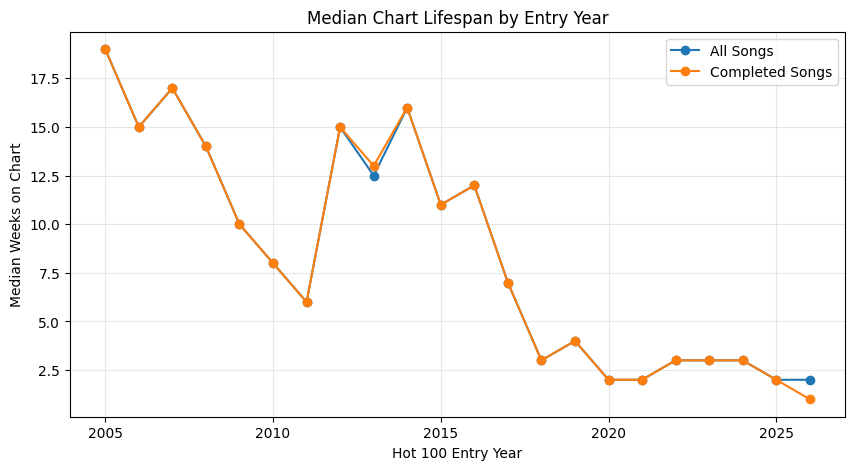

In [101]:
median_lifespan_all = (
    song_life
    .groupby("entry_year")["lifespan_weeks"]
    .median()
)

median_lifespan_completed = (
    song_life_completed
    .groupby("entry_year")["lifespan_weeks"]
    .median()
)

plt.figure(figsize=(10,5))
plt.plot(median_lifespan_all.index, median_lifespan_all.values, marker="o", label="All Songs")
plt.plot(median_lifespan_completed.index, median_lifespan_completed.values, marker="o", label="Completed Songs")
plt.xlabel("Hot 100 Entry Year")
plt.ylabel("Median Weeks on Chart")
plt.title("Median Chart Lifespan by Entry Year")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

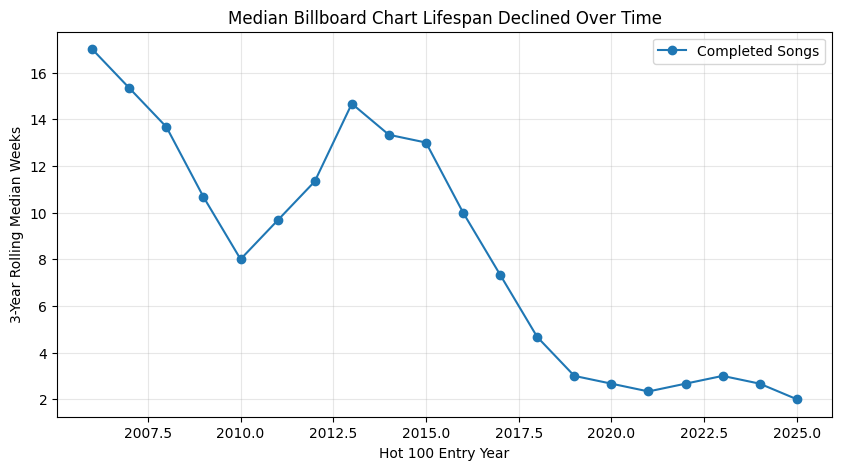

In [120]:
# median_lifespan_all_roll = median_lifespan_all.rolling(3, center=True).mean()
median_lifespan_completed_roll = median_lifespan_completed.rolling(3, center=True).mean()

plt.figure(figsize=(10,5))
# plt.plot(median_lifespan_all_roll.index, median_lifespan_all_roll.values, marker="o", label="All Songs")
plt.plot(median_lifespan_completed_roll.index, median_lifespan_completed_roll.values, marker="o", label="Completed Songs")
plt.xlabel("Hot 100 Entry Year")
plt.ylabel("3-Year Rolling Median Weeks")
plt.title("Median Billboard Chart Lifespan Declined Over Time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.axvline(
    x=2018,
    linestyle="--",
    linewidth=2,
    alpha=0.7,
    label="TikTok Era Begins"
)

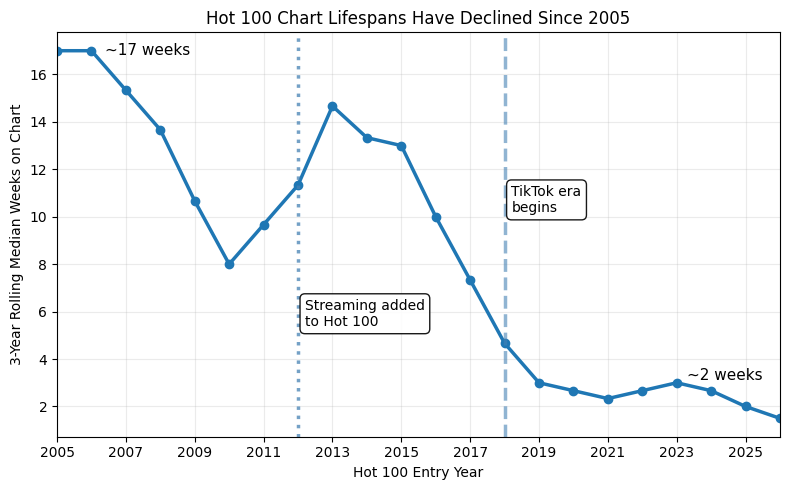

In [146]:
import matplotlib.pyplot as plt

# 3-year rolling median for completed songs only
median_lifespan_completed_roll = (
    median_lifespan_completed
    .rolling(
        window=3,
        center=True,
        min_periods=1  # allows edge years
    )
    .mean()
)

plt.figure(figsize=(8, 5))

# Main trend line
plt.plot(
    median_lifespan_completed_roll.index,
    median_lifespan_completed_roll.values,
    marker="o",
    linewidth=2.5
)

# Streaming milestone line
plt.axvline(
    x=2012,
    linestyle=":",
    linewidth=2.5,
    color="steelblue",
    alpha=0.75
)

# TikTok milestone line
plt.axvline(
    x=2018,
    linestyle="--",
    linewidth=2.5,
    color="steelblue",
    alpha=0.6
)

# Box styling for milestone labels
box_style = dict(
    facecolor="white",
    edgecolor="black",
    boxstyle="round,pad=0.35",
    alpha=0.9
)

'''
# Streaming label box
plt.text(
    2012.2,
    5.4,
    "Streaming added\nto Hot 100",
    fontsize=10,
    bbox=box_style
)

# TikTok label box
plt.text(
    2018.2,
    10.2,
    "TikTok era\nbegins",
    fontsize=10,
    bbox=box_style
)
'''
# Endpoint annotations
plt.text(
    2006.4,
    16.8,
    "~17 weeks",
    fontsize=11
)

plt.text(
    2023.3,
    3.1,
    "~2 weeks",
    fontsize=11
)

# Clean x-axis formatting
plt.xticks(range(2005, 2026, 2))
plt.xlim(2005, 2026)

# Labels and title
plt.xlabel("Hot 100 Entry Year")
plt.ylabel("3-Year Rolling Median Weeks on Chart")
plt.title("Hot 100 Chart Lifespans Have Declined Since 2005")

# Light grid
plt.grid(True, alpha=0.25)

plt.tight_layout()

# Poster-quality export
plt.savefig(
    "billboard_lifespan_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Era summary table (turn to bar chart)

### Tests run

In [110]:
era_summary = (
    song_life_completed
    .groupby("era")
    .agg(
        songs=("Song", "count"),
        median_lifespan=("lifespan_weeks", "median"),
        mean_lifespan=("lifespan_weeks", "mean"),
        median_time_to_peak=("time_to_peak", "median"),
        mean_top10_weeks=("top10_weeks", "mean"),
        mean_top40_weeks=("top40_weeks", "mean"),
        percent_top10=("peak_rank", lambda x: (x <= 10).mean() * 100),
        median_peak_rank=("peak_rank", "median")
    )
    .round(2)
)

era_summary

,songs,median_lifespan,mean_lifespan,median_time_to_peak,mean_top10_weeks,mean_top40_weeks,percent_top10,median_peak_rank
era,,,,,,,,
Post TikTok,5899,3.0,8.82,0.0,0.83,3.38,9.82,53.0
Pre TikTok,4464,13.0,13.46,4.0,1.33,5.34,14.40,50.0


In [158]:
import numpy as np
from scipy.stats import mannwhitneyu, chi2_contingency

# Make sure era is clean/consistent
song_life_completed["era"] = np.where(
    song_life_completed["entry_year"] < 2018,
    "Pre TikTok",
    "Post TikTok"
)

# Top 10 flag
song_life_completed["reached_top10"] = (
    song_life_completed["peak_rank"] <= 10
)

In [160]:
pre = song_life_completed.loc[
    song_life_completed["era"] == "Pre TikTok",
    "lifespan_weeks"
]

post = song_life_completed.loc[
    song_life_completed["era"] == "Post TikTok",
    "lifespan_weeks"
]

u, p = mannwhitneyu(pre, post, alternative="two-sided")

print(f"Lifespan U={u}")
print(f"Lifespan p={p}")

Lifespan U=17448725.0
Lifespan p=1.80138470375914e-159


In [162]:
from scipy.stats import mannwhitneyu

pre = song_life_completed.loc[
    song_life_completed["era"] == "Pre TikTok",
    "time_to_peak"
]

post = song_life_completed.loc[
    song_life_completed["era"] == "Post TikTok",
    "time_to_peak"
]

u, p = mannwhitneyu(pre, post)

print(f"U={u}")
print(f"p={p}")

U=18033539.0
p=3.084260495270774e-240


In [163]:
songs_per_year = (
    song_life_completed
    .groupby("entry_year")
    .size()
    .reset_index(name="songs")
)

songs_per_year["era"] = songs_per_year["entry_year"].apply(
    lambda x: "Pre TikTok" if x < 2018 else "Post TikTok"
)

from scipy.stats import mannwhitneyu

pre = songs_per_year.loc[
    songs_per_year["era"] == "Pre TikTok",
    "songs"
]

post = songs_per_year.loc[
    songs_per_year["era"] == "Post TikTok",
    "songs"
]

u, p = mannwhitneyu(pre, post)

print(f"U={u}")
print(f"p={p}")

U=13.0
p=0.0026556990473244895


In [165]:
from scipy.stats import chi2_contingency

song_life_completed["reached_top10"] = (
    song_life_completed["peak_rank"] <= 10
)

top10_table = pd.crosstab(
    song_life_completed["era"],
    song_life_completed["reached_top10"]
)

display(top10_table)

chi2, p, dof, expected = chi2_contingency(top10_table)

print("Chi-square:", chi2)
print("p-value:", p)

reached_top10,False,True
era,,
Post TikTok,4553,477
Pre TikTok,4588,745


Chi-square: 49.66289889747253
p-value: 1.8256584326739218e-12


### Summary table produced

In [170]:
import pandas as pd
import numpy as np

# -----------------------------
# 1. Make yearly song counts
# -----------------------------
songs_per_year = (
    song_life_completed
    .groupby("entry_year")
    .size()
    .reset_index(name="songs_per_year")
)

songs_per_year["era"] = np.where(
    songs_per_year["entry_year"] < 2018,
    "Pre TikTok",
    "Post TikTok"
)

# Average number of unique Hot 100 entries per year in each era
songs_per_year_summary = (
    songs_per_year
    .groupby("era")["songs_per_year"]
    .mean()
)

# -----------------------------
# 2. Make chart dynamics summary
# -----------------------------
summary_table = pd.DataFrame({
    "Metric": [
        "Median Lifespan (weeks)",
        "Median Time to Peak (weeks)",
        "% Reaching Top 10",
        "Avg. Songs Entering / Year"
    ],
    "Pre TikTok": [
        era_summary.loc["Pre TikTok", "median_lifespan"],
        era_summary.loc["Pre TikTok", "median_time_to_peak"],
        era_summary.loc["Pre TikTok", "percent_top10"],
        songs_per_year_summary.loc["Pre TikTok"]
    ],
    "Post TikTok": [
        era_summary.loc["Post TikTok", "median_lifespan"],
        era_summary.loc["Post TikTok", "median_time_to_peak"],
        era_summary.loc["Post TikTok", "percent_top10"],
        songs_per_year_summary.loc["Post TikTok"]
    ],
    "p-value": [
        "<0.001",
        "<0.001",
        "<0.001",
        "0.003"
    ]
})

# -----------------------------
# 3. Calculate percent change
# -----------------------------
summary_table["% Change"] = (
    (
        (summary_table["Post TikTok"] - summary_table["Pre TikTok"])
        / summary_table["Pre TikTok"]
    ) * 100
).round(1)

# Add + sign for increases
summary_table["% Change"] = summary_table["% Change"].apply(
    lambda x: f"+{x}%" if x > 0 else f"{x}%"
)

# -----------------------------
# 4. Round values for readability
# -----------------------------
summary_table["Pre TikTok"] = summary_table["Pre TikTok"].round(1)
summary_table["Post TikTok"] = summary_table["Post TikTok"].round(1)

summary_table = summary_table[
    [
        "Metric",
        "Pre TikTok",
        "Post TikTok",
        "% Change",
        "p-value"
    ]
]
display(summary_table)

# Optional export
summary_table.to_csv("chart_dynamics_summary_table.csv", index=False)

,Metric,Pre TikTok,Post TikTok,% Change,p-value
0,Median Lifespan (weeks),13.0,3.0,-76.9%,<0.001
1,Median Time to Peak (weeks),4.0,0.0,-100.0%,<0.001
2,% Reaching Top 10,14.4,9.8,-31.8%,<0.001
3,Avg. Songs Entering / Year,410.2,558.9,+36.2%,0.003


## Median time to peak by entry year (speed of popularity)

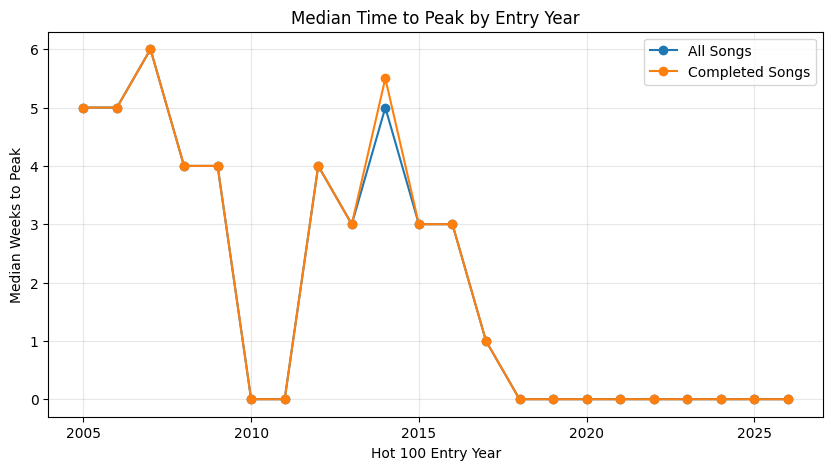

In [104]:
median_time_to_peak_all = (
    song_life
    .groupby("entry_year")["time_to_peak"]
    .median()
)

median_time_to_peak_completed = (
    song_life_completed
    .groupby("entry_year")["time_to_peak"]
    .median()
)

plt.figure(figsize=(10,5))
plt.plot(median_time_to_peak_all.index, median_time_to_peak_all.values, marker="o", label="All Songs")
plt.plot(median_time_to_peak_completed.index, median_time_to_peak_completed.values, marker="o", label="Completed Songs")
plt.xlabel("Hot 100 Entry Year")
plt.ylabel("Median Weeks to Peak")
plt.title("Median Time to Peak by Entry Year")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

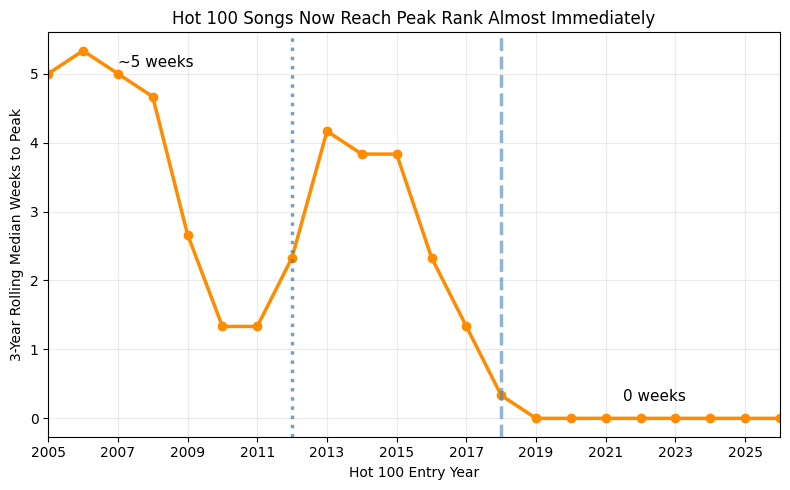

In [155]:
import matplotlib.pyplot as plt

# Median time to peak for completed songs only
median_time_to_peak_completed = (
    song_life_completed
    .groupby("entry_year")["time_to_peak"]
    .median()
)

# 3-year rolling median, allowing edge years to appear
median_time_to_peak_completed_roll = (
    median_time_to_peak_completed
    .rolling(
        window=3,
        center=True,
        min_periods=1  # keeps 2005 and 2026 endpoints visible
    )
    .mean()
)

plt.figure(figsize=(8, 5))

# Main trend line
plt.plot(
    median_time_to_peak_completed_roll.index,
    median_time_to_peak_completed_roll.values,
    marker="o",
    linewidth=2.5,
    color="darkorange"
)

# Streaming milestone line
plt.axvline(
    x=2012,
    linestyle=":",
    linewidth=2.5,
    color="steelblue",
    alpha=0.75
)

# TikTok milestone line
plt.axvline(
    x=2018,
    linestyle="--",
    linewidth=2.5,
    color="steelblue",
    alpha=0.6
)

# Box styling for milestone labels
box_style = dict(
    facecolor="white",
    edgecolor="black",
    boxstyle="round,pad=0.35",
    alpha=0.9
)

# Endpoint annotations
plt.text(
    2007.0,
    5.1,
    "~5 weeks",
    fontsize=11
)

plt.text(
    2021.5,
    0.25,
    "0 weeks",
    fontsize=11
)

# Clean x-axis formatting
plt.xticks(range(2005, 2026, 2))
plt.xlim(2005, 2026)

# Labels and title
plt.xlabel("Hot 100 Entry Year")
plt.ylabel("3-Year Rolling Median Weeks to Peak")
plt.title("Hot 100 Songs Now Reach Peak Rank Almost Immediately")

# Light grid
plt.grid(True, alpha=0.25)

plt.tight_layout()

# Poster-quality export
plt.savefig(
    "billboard_time_to_peak_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Number of New songs Entering Hot 100 (turnover)

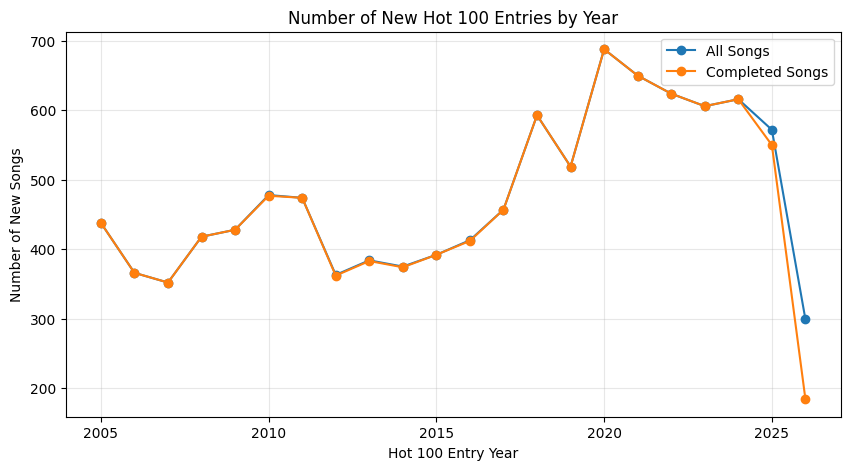

In [99]:
songs_per_year = (
    song_life
    .groupby("entry_year")
    .size()
)

completed_songs_per_year = (
    song_life_completed
    .groupby("entry_year")
    .size()
)

plt.figure(figsize=(10,5))
plt.plot(songs_per_year.index, songs_per_year.values, marker="o", label="All Songs")
plt.plot(completed_songs_per_year.index, completed_songs_per_year.values, marker="o", label="Completed Songs")
plt.xlabel("Hot 100 Entry Year")
plt.ylabel("Number of New Songs")
plt.title("Number of New Hot 100 Entries by Year")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Percent of hot 100 reaching top 10 (success probability)

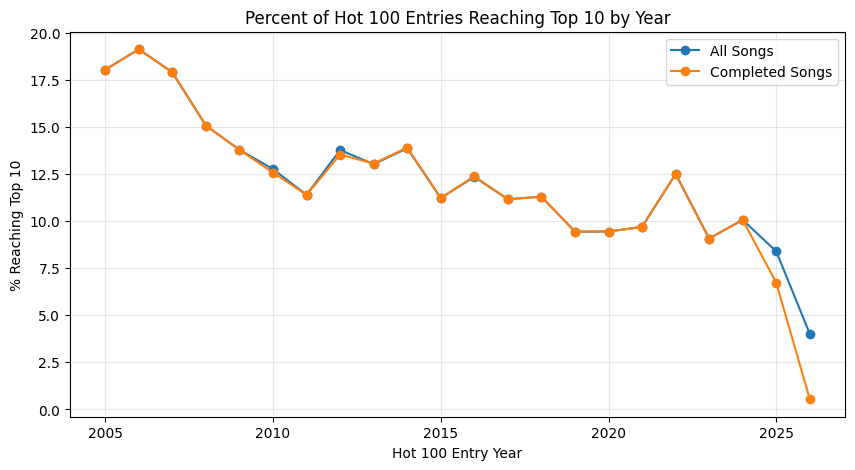

In [108]:
percent_top10_all = (
    song_life
    .groupby("entry_year")["peak_rank"]
    .apply(lambda x: (x <= 10).mean() * 100)
)

percent_top10_completed = (
    song_life_completed
    .groupby("entry_year")["peak_rank"]
    .apply(lambda x: (x <= 10).mean() * 100)
)

plt.figure(figsize=(10,5))
plt.plot(percent_top10_all.index, percent_top10_all.values, marker="o", label="All Songs")
plt.plot(percent_top10_completed.index, percent_top10_completed.values, marker="o", label="Completed Songs")
plt.xlabel("Hot 100 Entry Year")
plt.ylabel("% Reaching Top 10")
plt.title("Percent of Hot 100 Entries Reaching Top 10 by Year")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Rest

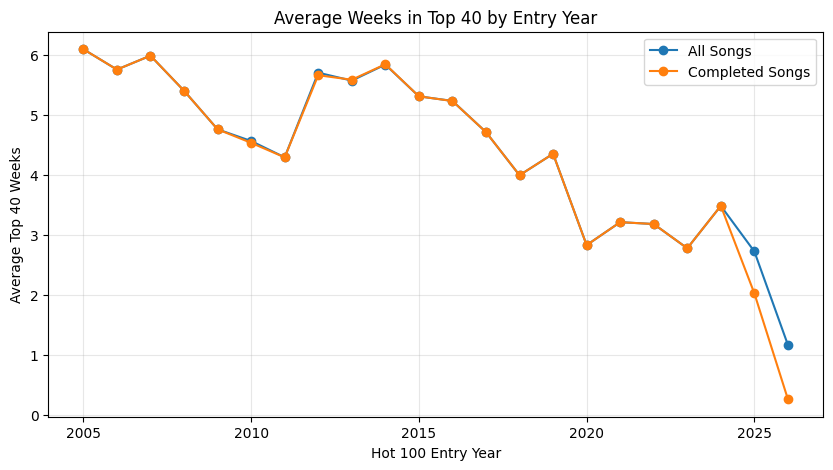

In [112]:
avg_top40_all = (
    song_life
    .groupby("entry_year")["top40_weeks"]
    .mean()
)

avg_top40_completed = (
    song_life_completed
    .groupby("entry_year")["top40_weeks"]
    .mean()
)

plt.figure(figsize=(10,5))
plt.plot(avg_top40_all.index, avg_top40_all.values, marker="o", label="All Songs")
plt.plot(avg_top40_completed.index, avg_top40_completed.values, marker="o", label="Completed Songs")
plt.xlabel("Hot 100 Entry Year")
plt.ylabel("Average Top 40 Weeks")
plt.title("Average Weeks in Top 40 by Entry Year")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

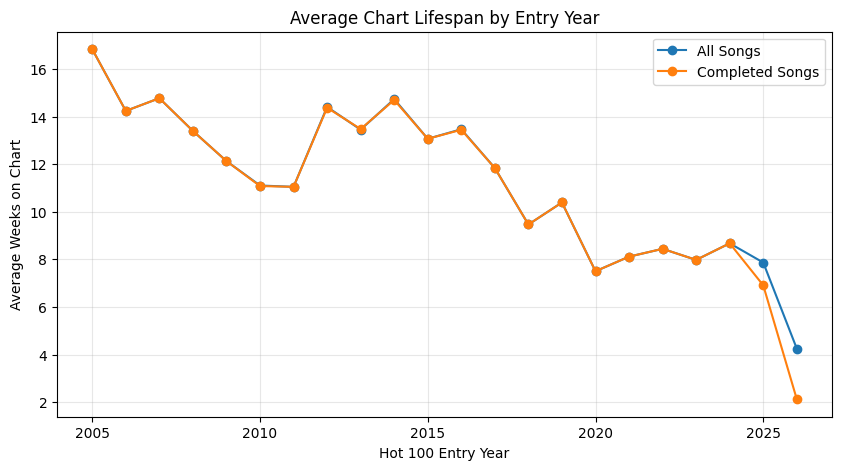

In [103]:
mean_lifespan_all = (
    song_life
    .groupby("entry_year")["lifespan_weeks"]
    .mean()
)

mean_lifespan_completed = (
    song_life_completed
    .groupby("entry_year")["lifespan_weeks"]
    .mean()
)

plt.figure(figsize=(10,5))
plt.plot(mean_lifespan_all.index, mean_lifespan_all.values, marker="o", label="All Songs")
plt.plot(mean_lifespan_completed.index, mean_lifespan_completed.values, marker="o", label="Completed Songs")
plt.xlabel("Hot 100 Entry Year")
plt.ylabel("Average Weeks on Chart")
plt.title("Average Chart Lifespan by Entry Year")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

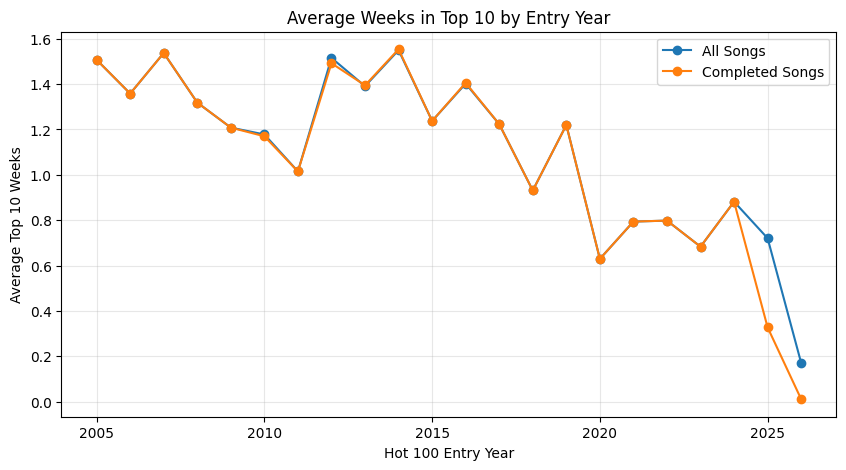

In [105]:
avg_top10_all = (
    song_life
    .groupby("entry_year")["top10_weeks"]
    .mean()
)

avg_top10_completed = (
    song_life_completed
    .groupby("entry_year")["top10_weeks"]
    .mean()
)

plt.figure(figsize=(10,5))
plt.plot(avg_top10_all.index, avg_top10_all.values, marker="o", label="All Songs")
plt.plot(avg_top10_completed.index, avg_top10_completed.values, marker="o", label="Completed Songs")
plt.xlabel("Hot 100 Entry Year")
plt.ylabel("Average Top 10 Weeks")
plt.title("Average Weeks in Top 10 by Entry Year")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

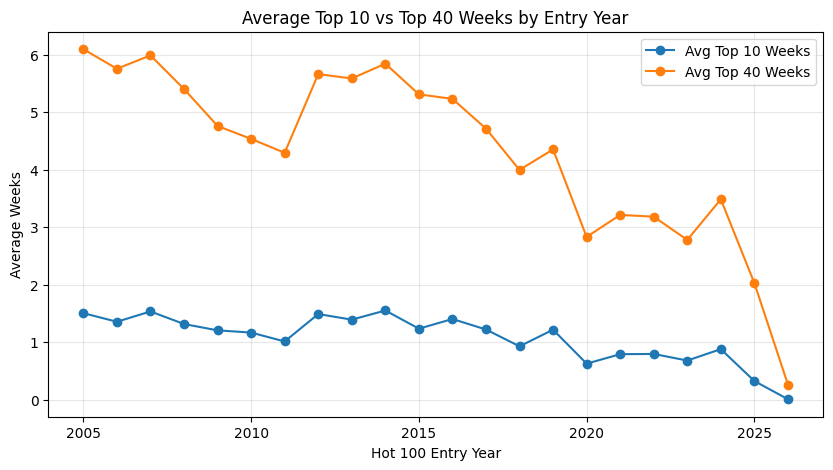

In [107]:
top_weeks_completed = (
    song_life_completed
    .groupby("entry_year")[["top10_weeks", "top40_weeks"]]
    .mean()
)

plt.figure(figsize=(10,5))
plt.plot(top_weeks_completed.index, top_weeks_completed["top10_weeks"], marker="o", label="Avg Top 10 Weeks")
plt.plot(top_weeks_completed.index, top_weeks_completed["top40_weeks"], marker="o", label="Avg Top 40 Weeks")
plt.xlabel("Hot 100 Entry Year")
plt.ylabel("Average Weeks")
plt.title("Average Top 10 vs Top 40 Weeks by Entry Year")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

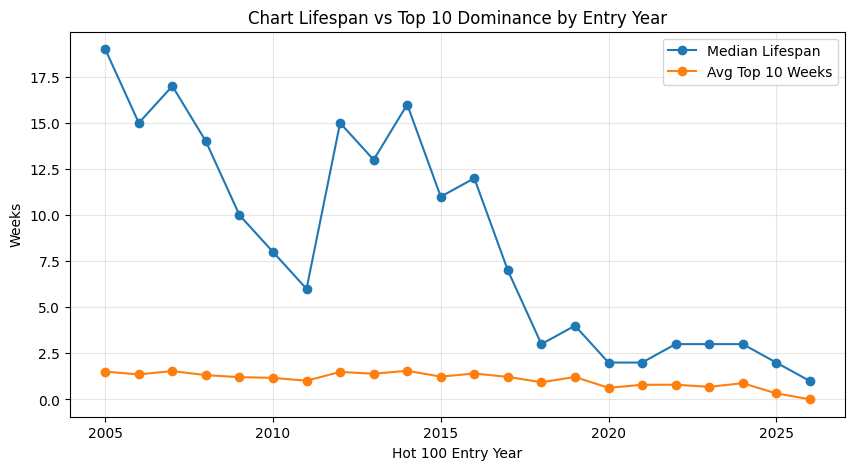

In [109]:
year_summary_completed = (
    song_life_completed
    .groupby("entry_year")
    .agg(
        median_lifespan=("lifespan_weeks", "median"),
        avg_top10_weeks=("top10_weeks", "mean"),
        percent_top10=("peak_rank", lambda x: (x <= 10).mean() * 100)
    )
)

plt.figure(figsize=(10,5))
plt.plot(year_summary_completed.index, year_summary_completed["median_lifespan"], marker="o", label="Median Lifespan")
plt.plot(year_summary_completed.index, year_summary_completed["avg_top10_weeks"], marker="o", label="Avg Top 10 Weeks")
plt.xlabel("Hot 100 Entry Year")
plt.ylabel("Weeks")
plt.title("Chart Lifespan vs Top 10 Dominance by Entry Year")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Apple Music Preview Matching

Goal:
Match Billboard songs to Apple Music tracks and retrieve
30-second preview URLs for audio feature extraction.

## Top40 separation

In [ ]:
# save the full Top 40 dataset

top40.to_csv(
    "top40_billboard_dataset.csv",
    index=False
)

print(top40.shape)

(4078, 17)


In [31]:
# create top 40
test_top40 = top40[["Song", "Artist"]].sample(
    10,
    random_state=42
).copy()

preview_results = []

for _, row in test_top40.iterrows():
    result = search_itunes_best_match(row["Song"], row["Artist"])
    preview_results.append(result)
    time.sleep(1.0)

preview_top40_test = pd.DataFrame(preview_results)

### imports

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import requests
import time
import re
from difflib import SequenceMatcher

## Helper Functions

The following functions:
- clean song titles
- extract main artists
- compute similarity scores
- evaluate match quality


### Pipeline

In [ ]:
Billboard song_life dataframe (song, artist)
        ↓
sample songs 
        ↓   
search Apple/iTunes API
        ↓
get up to 10 possible results
        ↓
score each result
        ↓
pick best result
        ↓
label match confidence
        ↓
save preview URL

Output: Preview DataFrame - [search_song
search_artist
matched_song
matched_artist
collection
preview_url
match_score
title_score
artist_score
version_penalty
match_status]

### Clean song + artist text

In [26]:
def clean_text(text):
    text = str(text).lower()
    text = text.replace('"', "")
    text = text.replace("'", "")
    text = re.sub(r"\(.*?\)", "", text)
    text = re.sub(r"\[.*?\]", "", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def get_main_artist(artist):
    artist = str(artist)
    artist = re.split(
        r" featuring | feat\. | feat | ft\. | ft | & | and |,",
        artist,
        flags=re.IGNORECASE
    )[0]
    return artist.strip()


def similarity(a, b):
    return SequenceMatcher(None, clean_text(a), clean_text(b)).ratio()

### Suspicious version penalty

In [27]:
bad_version_words = [
    "piano", "acoustic", "live", "remix", "karaoke",
    "instrumental", "sped up", "slowed", "cover",
    "tribute", "demo", "reimagined", "stripped",
    "version", "tribute", "originally performed",
    "kidz bop", "16 bit", "computer game"
]


# cleaner that PRESERVES words inside parentheses/brackets
# so things like "(Acoustic)" don't disappear

def simple_clean(text):
    text = str(text).lower()
    text = text.replace('"', "")
    text = text.replace("'", "")

    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


def version_penalty(track_name, collection_name):
    
    text = simple_clean(
        str(track_name) + " " + str(collection_name)
    )

    penalty = 0

    for word in bad_version_words:
        if word in text:
            penalty += 0.25

    return penalty

### Score each Apple result

In [28]:
def score_match(search_song, search_artist, result):
    matched_song = result.get("trackName", "")
    matched_artist = result.get("artistName", "")
    collection = result.get("collectionName", "")
    preview_url = result.get("previewUrl", None)
    
    title_score = similarity(search_song, matched_song)
    artist_score = similarity(get_main_artist(search_artist), matched_artist)
    penalty = version_penalty(matched_song, collection)
    
    preview_bonus = 0.05 if preview_url else -0.30
    
    final_score = (
        0.65 * title_score
        + 0.30 * artist_score
        + preview_bonus
        - penalty
    )
    
    return final_score, title_score, artist_score, penalty

### Search Apple and pick best match + with backoff wrapper function

In [29]:
def search_itunes_best_match(song, artist):
    """
    Search Apple/iTunes API, score possible matches, and return the best result.
    Also collects Apple metadata:
    - preview_url
    - release date
    - duration
    - genre
    """

    url = "https://itunes.apple.com/search"

    search_term = f"{clean_text(song)} {clean_text(get_main_artist(artist))}"

    params = {
        "term": search_term,
        "media": "music",
        "entity": "song",
        "limit": 10
    }

    try:
        response = requests.get(url, params=params, timeout=10)

    except requests.exceptions.RequestException:
        return {
            "search_song": song,
            "search_artist": artist,
            "search_term": search_term,
            "failure_reason": "REQUEST_ERROR"
        }

    if response.status_code != 200:
        return {
            "search_song": song,
            "search_artist": artist,
            "search_term": search_term,
            "failure_reason": "BAD_STATUS",
            "status_code": response.status_code
        }

    try:
        data = response.json()

    except ValueError:
        return {
            "search_song": song,
            "search_artist": artist,
            "search_term": search_term,
            "failure_reason": "JSON_ERROR",
            "response_preview": response.text[:200]
        }

    if data.get("resultCount", 0) == 0:
        return {
            "search_song": song,
            "search_artist": artist,
            "search_term": search_term,
            "failure_reason": "NO_RESULTS"
        }

    scored_results = []

    for result in data["results"]:
        score, title_score, artist_score, penalty = score_match(song, artist, result)
        scored_results.append((score, title_score, artist_score, penalty, result))

    best_score, title_score, artist_score, penalty, best_result = max(
        scored_results,
        key=lambda x: x[0]
    )

    preview_url = best_result.get("previewUrl")
    track_time_ms = best_result.get("trackTimeMillis")

    if track_time_ms is not None:
        duration_sec = track_time_ms / 1000
    else:
        duration_sec = None

    if (
        best_score >= 0.92
        and title_score >= 0.90
        and artist_score >= 0.65
        and penalty == 0
        and preview_url is not None
    ):
        match_status = "AUTO_ACCEPT"

    elif (
        best_score >= 0.80
        and title_score >= 0.90
        and artist_score >= 0.50
        and penalty == 0
        and preview_url is not None
    ):
        match_status = "REVIEW"

    else:
        match_status = "LOW_CONFIDENCE"

    return {
        # original Billboard search info
        "search_song": song,
        "search_artist": artist,
        "search_term": search_term,

        # Apple matched info
        "matched_song": best_result.get("trackName"),
        "matched_artist": best_result.get("artistName"),
        "collection": best_result.get("collectionName"),
        "preview_url": preview_url,

        # Apple metadata
        "apple_release_date": best_result.get("releaseDate"),
        "apple_track_time_ms": track_time_ms,
        "apple_duration_sec": duration_sec,
        "apple_genre": best_result.get("primaryGenreName"),
        "apple_collection": best_result.get("collectionName"),
        "apple_track_id": best_result.get("trackId"),
        "apple_artist_id": best_result.get("artistId"),

        # matching diagnostics
        "match_score": best_score,
        "title_score": title_score,
        "artist_score": artist_score,
        "version_penalty": penalty,
        "match_status": match_status,
        "failure_reason": "SUCCESS"
    }

In [38]:
def search_itunes_best_match_with_backoff(
    song,
    artist,
    max_retries=3,
    base_sleep=10
):
    """
    Wrapper around search_itunes_best_match().
    If Apple returns 429/403 or a request-like failure, wait and retry.
    """

    for attempt in range(max_retries + 1):

        result = search_itunes_best_match(song, artist)

        failure_reason = result.get("failure_reason")
        status_code = result.get("status_code")

        # success or non-rate-limit failure
        if failure_reason != "BAD_STATUS":
            return result

        # rate limit / temporary block
        if status_code in [429, 403]:

            wait_time = base_sleep * (attempt + 1)

            print(
                f"Rate limit/status {status_code} for: {song} — {artist}. "
                f"Waiting {wait_time}s before retry {attempt + 1}/{max_retries}..."
            )

            time.sleep(wait_time)

        else:
            return result

    # if retries fail, return final result
    return result

### Artist overlap

In [30]:
def artist_overlap(search_artist, matched_artist):
    search_clean = clean_text(search_artist)
    matched_clean = clean_text(matched_artist)

    search_words = set(search_clean.split())
    matched_words = set(matched_clean.split())

    if len(search_words) == 0 or len(matched_words) == 0:
        return 0

    overlap = search_words.intersection(matched_words)
    return len(overlap) / min(len(search_words), len(matched_words))

## Test on 100 random songs

In [94]:
test_songs = song_life[["Song", "Artist"]].sample(
    100,
    random_state=42
).copy()

preview_results = []

for _, row in test_songs.iterrows():
    result = search_itunes_best_match(row["Song"], row["Artist"])
    preview_results.append(result)
    time.sleep(0.5)

preview_df = pd.DataFrame(preview_results)

#### inspect results

In [50]:
len(preview_df), len(failed)

(53, 47)

In [95]:
preview_df["failure_reason"].value_counts()

failure_reason
SUCCESS    100
Name: count, dtype: int64

In [96]:
preview_df["match_status"].value_counts(dropna=False)

match_status
AUTO_ACCEPT       82
REVIEW            11
LOW_CONFIDENCE     7
Name: count, dtype: int64

In [58]:
preview_df.sort_values("match_score").head(20)

,search_song,search_artist,matched_song,matched_artist,collection,preview_url,match_score,title_score,artist_score,version_penalty,match_status
22,M3tamorphosis,Playboi Carti Featuring Kid Cudi,M3tamorphosis (8-Bit Computer Game Version),8-Bit Arcade,"By Request, Vol. 117",https://audio-ssl.itunes.apple.com/itunes-asse...,0.272000,1.000000,0.240000,0.5,LOW_CONFIDENCE
68,Working,Tate McRae X Khalid,she's all i wanna be,Tate McRae,she's all i wanna be - Single,https://audio-ssl.itunes.apple.com/itunes-asse...,0.356897,0.153846,0.689655,0.0,LOW_CONFIDENCE
65,A Boy Is A Gun,"""Tyler, The Creator""",Sugar On My Tongue,"Tyler, The Creator",DON'T TAP THE GLASS,https://audio-ssl.itunes.apple.com/itunes-asse...,0.470739,0.437500,0.454545,0.0,LOW_CONFIDENCE
83,You Got Em,Lil Durk,All My Life (feat. J. Cole),Lil Durk,All My Life (feat. J. Cole) - Single,https://audio-ssl.itunes.apple.com/itunes-asse...,0.535714,0.285714,1.000000,0.0,LOW_CONFIDENCE
11,Got The Guap,Lil Uzi Vert Featuring Young Thug,Sauce It Up,Lil Uzi Vert,Luv Is Rage 2,https://audio-ssl.itunes.apple.com/itunes-asse...,0.576087,0.347826,1.000000,0.0,LOW_CONFIDENCE
53,Anyways,Zach Bryan,Always Willin',Zach Bryan,With Heaven On Top,https://audio-ssl.itunes.apple.com/itunes-asse...,0.675000,0.500000,1.000000,0.0,LOW_CONFIDENCE
16,Twisted Transistor,Korn,Twisted Transistor,Music Box Mania,MBM Performs Korn - EP,https://audio-ssl.itunes.apple.com/itunes-asse...,0.763158,1.000000,0.210526,0.0,LOW_CONFIDENCE
55,Finally Found You,Enrique Iglesias Featuring Sammy Adams,Finally Found You,Morcheeba,Head Up High,https://audio-ssl.itunes.apple.com/itunes-asse...,0.772000,1.000000,0.240000,0.0,LOW_CONFIDENCE
26,Save Me,Jelly Roll With Lainey Wilson,Save Me (with Lainey Wilson),Jelly Roll,Whitsitt Chapel,https://audio-ssl.itunes.apple.com/itunes-asse...,0.853846,1.000000,0.512821,0.0,REVIEW
40,No Opp Left Behind,21 Savage & Metro Boomin,No Opp Left Behind,21 Savage & Metro Boomin,SAVAGE MODE II,https://audio-ssl.itunes.apple.com/itunes-asse...,0.874194,1.000000,0.580645,0.0,REVIEW


In [49]:
preview_df[
    ["search_song", "search_artist", "matched_song", "matched_artist", 
     "collection", "match_score", "match_status"]
].sample(20, random_state=1)

,search_song,search_artist,matched_song,matched_artist,collection,match_score,match_status
30,Friday Night,Eric Paslay,Friday Night,Eric Paslay,Eric Paslay,1.000000,AUTO_ACCEPT
2,Otis,Jay Z Kanye West Featuring Otis Redding,Otis (feat. Otis Redding),Kanye West & JAŸ-Z,Watch the Throne (Deluxe Version),0.893548,AUTO_ACCEPT
51,X2,Lil Uzi Vert,x2,Lil Uzi Vert,Pink Tape,1.000000,AUTO_ACCEPT
32,Beg For It,Iggy Azalea Featuring M0,Beg For It (feat. M.O),Iggy Azalea,Reclassified,1.000000,AUTO_ACCEPT
31,I'm Still A Guy,Brad Paisley,I'm Still a Guy,Brad Paisley,5th Gear (Bonus Track Version),1.000000,AUTO_ACCEPT
46,Electricity,Silk City x Dua Lipa,Electricity (feat. Dua Lipa) [Acoustic],Silk City & Dua Lipa (Diplo and Marc Ronson),Electricity (feat. Dua Lipa) [Acoustic] - Single,0.984211,AUTO_ACCEPT
34,Body Language,Jesse McCartney Featuring T-Pain,Body Language (feat. T-Pain),Jesse McCartney,Body Language (feat. T-Pain) - Single,1.000000,AUTO_ACCEPT
39,No Opp Left Behind,21 Savage & Metro Boomin,No Opp Left Behind,21 Savage & Metro Boomin,SAVAGE MODE II,0.874194,AUTO_ACCEPT
45,Social Distancing,Lil Baby,Social Distancing,Lil Baby,My Turn (Deluxe),1.000000,AUTO_ACCEPT
19,You Complete Me,Keyshia Cole,You Complete Me,Keyshia Cole,A Different Me,1.000000,AUTO_ACCEPT


In [60]:
auto_accept = preview_df[
    preview_df["match_status"] == "AUTO_ACCEPT"
]

In [63]:
auto_accept[
    [
        "search_song",
        "search_artist",
        "matched_song",
        "matched_artist",
        "match_score"
    ]
].head()

,search_song,search_artist,matched_song,matched_artist,match_score
0,"""Girl, Get Up.""",Doechii & SZA,"girl, get up.",Doechii & SZA,0.933333
1,Bright,Echosmith,Bright,Echosmith,1.000000
3,Paramedic!,SOB X RBE,Paramedic!,SOB X RBE,1.000000
4,Let It Go,Keyshia Cole Featuring Missy Elliott & Lil Kim,Let It Go (feat. Missy Elliott & Lil 'Kim),Keyshia Cole,1.000000
5,I Wrote The Book,Morgan Wallen,I Wrote The Book,Morgan Wallen,1.000000


In [71]:
auto_accept.sample(20, random_state=42)

,search_song,search_artist,matched_song,matched_artist,collection,preview_url,match_score,title_score,artist_score,version_penalty,match_status
35,Made My Hoe Faint,Future,MADE MY HOE FAINT,Future,MIXTAPE PLUTO,https://audio-ssl.itunes.apple.com/itunes-asse...,1.000000,1.0,1.000000,0.0,AUTO_ACCEPT
0,"""Girl, Get Up.""",Doechii & SZA,"girl, get up.",Doechii & SZA,"girl, get up. - Single",https://audio-ssl.itunes.apple.com/itunes-asse...,0.933333,1.0,0.777778,0.0,AUTO_ACCEPT
27,Just Say Dat,Gunna,just say dat,Gunna,The Last Wun,https://audio-ssl.itunes.apple.com/itunes-asse...,1.000000,1.0,1.000000,0.0,AUTO_ACCEPT
36,Bout A Million,Pop Smoke Featuring 21 Savage & 42 Dugg,Bout A Million (feat. 21 Savage & 42 Dugg),Pop Smoke,Faith (Deluxe),https://audio-ssl.itunes.apple.com/itunes-asse...,1.000000,1.0,1.000000,0.0,AUTO_ACCEPT
21,"""Heads Carolina, Tails California""",Danielle Bradbery,"Heads Carolina, Tails California (The Voice Pe...",Danielle Bradbery,The Complete Season 4 Collection (The Voice Pe...,https://audio-ssl.itunes.apple.com/itunes-asse...,1.000000,1.0,1.000000,0.0,AUTO_ACCEPT
33,Who,Jimin,Who,Jimin,MUSE,https://audio-ssl.itunes.apple.com/itunes-asse...,1.000000,1.0,1.000000,0.0,AUTO_ACCEPT
12,The Sweet Escape,Gwen Stefani Featuring Akon,The Sweet Escape (feat. Akon),Gwen Stefani,The Sweet Escape,https://audio-ssl.itunes.apple.com/itunes-asse...,1.000000,1.0,1.000000,0.0,AUTO_ACCEPT
67,Wishing,"""DJ Drama Featuring Chris Brown, Skeme & Lyquin""","Wishing (feat. Chris Brown, Skeme & Lyquin)",DJ Drama,"Wishing (feat. Chris Brown, Skeme & Lyquin) - ...",https://audio-ssl.itunes.apple.com/itunes-asse...,1.000000,1.0,1.000000,0.0,AUTO_ACCEPT
5,I Wrote The Book,Morgan Wallen,I Wrote The Book,Morgan Wallen,One Thing At A Time,https://audio-ssl.itunes.apple.com/itunes-asse...,1.000000,1.0,1.000000,0.0,AUTO_ACCEPT
14,Like A Wrecking Ball,Eric Church,Like a Wrecking Ball,Eric Church,The Outsiders,https://audio-ssl.itunes.apple.com/itunes-asse...,1.000000,1.0,1.000000,0.0,AUTO_ACCEPT


## Test 250 Songs

In [115]:
test_songs = song_life[["Song", "Artist"]].sample(
    250,
    random_state=42
).copy()

In [116]:
preview_results = []

for _, row in test_songs.iterrows():
    result = search_itunes_best_match(row["Song"], row["Artist"])
    preview_results.append(result)
    time.sleep(1.0)

preview_df = pd.DataFrame(preview_results)

preview_df["failure_reason"].value_counts()

failure_reason
SUCCESS    250
Name: count, dtype: int64

In [124]:
preview_df["match_status"].value_counts(dropna=False)

match_status
AUTO_ACCEPT       206
LOW_CONFIDENCE     24
REVIEW             20
Name: count, dtype: int64

In [125]:
preview_df["artist_overlap"] = preview_df.apply(
    lambda row: artist_overlap(row["search_artist"], row["matched_artist"]),
    axis=1
)

preview_df["usable_match"] = (
    (preview_df["match_status"] == "AUTO_ACCEPT")
    |
    (
        (preview_df["title_score"] >= 0.95)
        & (preview_df["artist_overlap"] >= 0.40)
        & (preview_df["version_penalty"] == 0)
        & (preview_df["preview_url"].notna())
    )
)

In [126]:
preview_df[
    (preview_df["usable_match"] == True)
    & (preview_df["match_status"] != "AUTO_ACCEPT")
][
    ["search_song", "search_artist", "matched_song", "matched_artist",
     "title_score", "artist_score", "artist_overlap", "version_penalty", "match_status"]
].sort_values("artist_overlap").head(30)

,search_song,search_artist,matched_song,matched_artist,title_score,artist_score,artist_overlap,version_penalty,match_status
137,No One Mourns The Wicked,"""Ariana Grande Featuring Andy Nyman, Courtney-...","No One Mourns the Wicked (feat. Andy Nyman, Co...",Wicked Movie Cast & Ariana Grande,1.0,0.590909,0.40,0.0,REVIEW
2,Otis,Jay Z Kanye West Featuring Otis Redding,Otis (feat. Otis Redding),Kanye West & JAŸ-Z,1.0,0.645161,0.75,0.0,REVIEW
181,Now Or Never,High School Musical 3 Cast,Now or Never,The Cast of High School Musical,1.0,0.666667,0.80,0.0,REVIEW
218,OK Not To Be OK,Marshmello & Demi Lovato,OK Not To Be OK,Marshmello & Demi Lovato,1.0,0.625000,1.00,0.0,REVIEW
216,Sharks,"""Lil Wayne, Jelly Roll & Big Sean""",Sharks,"Lil Wayne, Jelly Roll & Big Sean",1.0,0.473684,1.00,0.0,LOW_CONFIDENCE
203,Fine China,Future & Juice WRLD,Fine China,Future & Juice WRLD,1.0,0.521739,1.00,0.0,REVIEW
164,Amen,Shaboozey & Jelly Roll,Amen,Shaboozey & Jelly Roll,1.0,0.620690,1.00,0.0,REVIEW
125,Hate Me,Ellie Goulding & Juice WRLD,Hate Me,Ellie Goulding & Juice WRLD,1.0,0.717949,1.00,0.0,REVIEW
110,Santa Baby,Eartha Kitt With Henri Rene And His Orchestra,Santa Baby (with Henri René and His Orchestra),Eartha Kitt,1.0,0.578947,1.00,0.0,REVIEW
219,We Own It (Fast & Furious),2 Chainz & Wiz Khalifa,We Own It (Fast & Furious),2 Chainz & Wiz Khalifa,1.0,0.571429,1.00,0.0,REVIEW


In [127]:
auto_accept_count = (
    preview_df["match_status"] == "AUTO_ACCEPT"
).sum()

usable_count = preview_df["usable_match"].sum()

print("AUTO_ACCEPT:", auto_accept_count)
print("USABLE:", usable_count)
print("Recovered:", usable_count - auto_accept_count)

AUTO_ACCEPT: 206
USABLE: 227
Recovered: 21


In [118]:
preview_df[
    preview_df["match_status"] != "AUTO_ACCEPT"
][
    ["search_song", "search_artist", "matched_song", "matched_artist",
     "collection", "match_score", "title_score", "artist_score", "version_penalty", "match_status"]
].sort_values("match_score").head(30)

,search_song,search_artist,matched_song,matched_artist,collection,match_score,title_score,artist_score,version_penalty,match_status
22,M3tamorphosis,Playboi Carti Featuring Kid Cudi,M3tamorphosis (8-Bit Computer Game Version),8-Bit Arcade,"By Request, Vol. 117",0.272000,1.000000,0.240000,0.50,LOW_CONFIDENCE
68,Working,Tate McRae X Khalid,she's all i wanna be,Tate McRae,she's all i wanna be - Single,0.356897,0.153846,0.689655,0.00,LOW_CONFIDENCE
153,Dis 1 Got It,Playboi Carti,Let It Go (Frozen),Lullaby Baby Trio,Disney Lullabies Classic Renditions of Disney ...,0.397619,0.380952,0.333333,0.00,LOW_CONFIDENCE
83,You Got Em,Lil Durk,All My Life (feat. J. Cole),Lil Durk,All My Life (feat. J. Cole) - Single,0.535714,0.285714,1.000000,0.00,LOW_CONFIDENCE
226,F**k The Industry Pt. 2,YoungBoy Never Broke Again,Make No Sense,YoungBoy Never Broke Again,AI YoungBoy 2,0.541176,0.294118,1.000000,0.00,LOW_CONFIDENCE
186,Untouchable,YoungBoy Never Broke Again,Slime Mentality,YoungBoy Never Broke Again,AI YoungBoy 2,0.550000,0.307692,1.000000,0.00,LOW_CONFIDENCE
193,Outfit,Lil Baby & 21 Savage,Close Friends,Lil Baby,Drip Harder,0.555263,0.315789,1.000000,0.00,LOW_CONFIDENCE
11,Got The Guap,Lil Uzi Vert Featuring Young Thug,Sauce It Up,Lil Uzi Vert,Luv Is Rage 2,0.576087,0.347826,1.000000,0.00,LOW_CONFIDENCE
182,Cold Heart (PNAU Remix),Elton John & Dua Lipa,Cold Heart (PNAU Remix),Elton John & Dua Lipa,The Lockdown Sessions,0.656897,1.000000,0.689655,0.25,LOW_CONFIDENCE
53,Anyways,Zach Bryan,Always Willin',Zach Bryan,With Heaven On Top,0.675000,0.500000,1.000000,0.00,LOW_CONFIDENCE


In [119]:
preview_df[
    preview_df["match_status"] == "AUTO_ACCEPT"
][
    [
        "search_song",
        "search_artist",
        "matched_song",
        "matched_artist"
    ]
].sample(50, random_state=1)

,search_song,search_artist,matched_song,matched_artist
96,I Smile,Kirk Franklin,I Smile,Kirk Franklin
119,Come Away To The Water,Maroon 5 Featuring Rozzi Crane,Come Away to the Water (feat. Rozzi Crane),Maroon 5
185,Flocky Flocky,Don Toliver Featuring Travis Scott,Flocky Flocky (feat. Travis Scott),Don Toliver
52,Electricity,Silk City x Dua Lipa,Electricity (feat. Diplo & Mark Ronson),"Silk City, Dua Lipa"
48,Chill Bill,Rob $tone Featuring J. Davi$ & Spooks,Chill Bill (feat. J. Davi$ & Spooks),Rob $tone
84,Keep Your Head Up,Andy Grammer,Keep Your Head Up,Andy Grammer
120,Defying Gravity,Cynthia Erivo Featuring Ariana Grande,Defying Gravity (feat. Ariana Grande),Cynthia Erivo
21,"""Heads Carolina, Tails California""",Danielle Bradbery,"Heads Carolina, Tails California (The Voice Pe...",Danielle Bradbery
187,Evacuate The Dancefloor,Cascada,Evacuate the Dancefloor,Cascada
78,Yellow Flicker Beat,Lorde,Yellow Flicker Beat,Lorde


In [120]:
review_df = preview_df[
    preview_df["match_status"] != "AUTO_ACCEPT"
].copy()

review_df[
    [
        "search_song",
        "search_artist",
        "matched_song",
        "matched_artist",
        "title_score",
        "artist_score",
        "match_status"
    ]
].head(50)

,search_song,search_artist,matched_song,matched_artist,title_score,artist_score,match_status
2,Otis,Jay Z Kanye West Featuring Otis Redding,Otis (feat. Otis Redding),Kanye West & JAŸ-Z,1.000000,0.645161,REVIEW
11,Got The Guap,Lil Uzi Vert Featuring Young Thug,Sauce It Up,Lil Uzi Vert,0.347826,1.000000,LOW_CONFIDENCE
16,Twisted Transistor,Korn,Twisted Transistor,Music Box Mania,1.000000,0.210526,LOW_CONFIDENCE
22,M3tamorphosis,Playboi Carti Featuring Kid Cudi,M3tamorphosis (8-Bit Computer Game Version),8-Bit Arcade,1.000000,0.240000,LOW_CONFIDENCE
26,Save Me,Jelly Roll With Lainey Wilson,Save Me (with Lainey Wilson),Jelly Roll,1.000000,0.512821,REVIEW
40,No Opp Left Behind,21 Savage & Metro Boomin,No Opp Left Behind,21 Savage & Metro Boomin,1.000000,0.580645,REVIEW
41,Hummingbird,Metro Boomin & James Blake,Hummingbird,Metro Boomin & James Blake,1.000000,0.666667,REVIEW
43,Mr. Morale,Kendrick Lamar & Tanna Leone,Mr. Morale,Kendrick Lamar & Tanna Leone,1.000000,0.700000,REVIEW
53,Anyways,Zach Bryan,Always Willin',Zach Bryan,0.500000,1.000000,LOW_CONFIDENCE
55,Finally Found You,Enrique Iglesias Featuring Sammy Adams,Finally Found You,EDGAR SIRANTANG,1.000000,0.387097,LOW_CONFIDENCE


## Test 250 more

In [128]:
test_songs_2 = song_life[["Song", "Artist"]].sample(
    250,
    random_state=99
).copy()

preview_results_2 = []

for _, row in test_songs_2.iterrows():
    result = search_itunes_best_match(row["Song"], row["Artist"])
    preview_results_2.append(result)
    time.sleep(1.0)

preview_df_2 = pd.DataFrame(preview_results_2)

In [129]:
preview_df_2["artist_overlap"] = preview_df_2.apply(
    lambda row: artist_overlap(row["search_artist"], row["matched_artist"]),
    axis=1
)

preview_df_2["usable_match"] = (
    (preview_df_2["match_status"] == "AUTO_ACCEPT")
    |
    (
        (preview_df_2["title_score"] >= 0.95)
        & (preview_df_2["artist_overlap"] >= 0.40)
        & (preview_df_2["version_penalty"] == 0)
        & (preview_df_2["preview_url"].notna())
    )
)

In [130]:
preview_df_2["failure_reason"].value_counts()

failure_reason
SUCCESS       240
BAD_STATUS      9
NO_RESULTS      1
Name: count, dtype: int64

In [131]:
preview_df_2["match_status"].value_counts(dropna=False)

match_status
AUTO_ACCEPT       193
LOW_CONFIDENCE     30
REVIEW             17
NaN                10
Name: count, dtype: int64

In [132]:
preview_df_2["usable_match"].value_counts()

usable_match
True     214
False     36
Name: count, dtype: int64

In [133]:
preview_df_2[
    (preview_df_2["usable_match"] == True)
    & (preview_df_2["match_status"] != "AUTO_ACCEPT")
][
    ["search_song", "search_artist", "matched_song", "matched_artist",
     "title_score", "artist_overlap", "version_penalty", "match_status"]
].head(30)

,search_song,search_artist,matched_song,matched_artist,title_score,artist_overlap,version_penalty,match_status
6,The Adventures Of Moon Man & Slim Shady,Kid Cudi & Eminem,The Adventures of Moon Man & Slim Shady,Kid Cudi & Eminem,1.0,1.0,0.0,REVIEW
36,Sunflower (Spider-Man: Into The Spider-Verse),Post Malone & Swae Lee,Sunflower (Spider-Man: Into the Spider-Verse),Post Malone & Swae Lee,1.0,1.0,0.0,REVIEW
38,For You (Fifty Shades Freed),Liam Payne & Rita Ora,For You (Fifty Shades Freed),Liam Payne & Rita Ora,1.0,1.0,0.0,REVIEW
48,Rumors,Lizzo Featuring Cardi B,Rumors,Lizzo & Cardi B,1.0,1.0,0.0,REVIEW
50,LV Bag,"""Don Toliver, J-Hope, Pharrell Williams & Speedy""",LV Bag (feat. Pharrell Williams),"Don Toliver, Speedy & j-hope",1.0,1.0,0.0,REVIEW
55,HVN On Earth,Lil Tecca & Kodak Black,HVN ON EARTH,Lil Tecca & Kodak Black,1.0,1.0,0.0,REVIEW
67,Potion,"""Calvin Harris, Dua Lipa & Young Thug""",Potion (Mixed),"Calvin Harris, Young Thug & Dua Lipa",1.0,1.0,0.0,REVIEW
70,OK Not To Be OK,Marshmello & Demi Lovato,OK Not To Be OK,Marshmello & Demi Lovato,1.0,1.0,0.0,REVIEW
85,Bandit,Juice WRLD & YoungBoy Never Broke Again,Bandit,Juice WRLD & YoungBoy Never Broke Again,1.0,1.0,0.0,LOW_CONFIDENCE
88,One Right Now,Post Malone & The Weeknd,One Right Now,Post Malone & The Weeknd,1.0,1.0,0.0,REVIEW


## Test 150 Songs

In [104]:
test_songs = song_life[["Song", "Artist"]].sample(
    150,
    random_state=42
).copy()

In [106]:
preview_results = []

for _, row in test_songs.iterrows():
    result = search_itunes_best_match(row["Song"], row["Artist"])
    preview_results.append(result)
    time.sleep(1.0)

preview_df = pd.DataFrame(preview_results)

preview_df["failure_reason"].value_counts()

failure_reason
SUCCESS    150
Name: count, dtype: int64

## Testing 500 songs

In [82]:
# test the Apple matching pipeline on 500 random Billboard songs

test_songs = song_life[["Song", "Artist"]].sample(
    500,
    random_state=42
).copy()

test_songs.head()

,Song,Artist
33,"""Girl, Get Up.""",Doechii & SZA
1432,Bright,Echosmith
6779,Otis,Jay Z Kanye West Featuring Otis Redding
6901,Paramedic!,SOB X RBE
5211,Let It Go,Keyshia Cole Featuring Missy Elliott & Lil Kim


In [83]:
# run

preview_results = []
failed = []

for _, row in test_songs.iterrows():
    
    result = search_itunes_best_match(
        row["Song"],
        row["Artist"]
    )
    
    # if Apple search fails completely, save the song for later inspection
    if result is None:
        failed.append((row["Song"], row["Artist"]))
    
    # if Apple returns a possible match, save the scored result
    else:
        preview_results.append(result)
    
    # slow down requests so we don't hammer the API
    time.sleep(0.2)

preview_df = pd.DataFrame(preview_results)

In [87]:
# how many matched vs failed completely?

print("Matched:", len(preview_df))
print("Failed:", len(failed))

Matched: 60
Failed: 440


### checks for after test:

In [80]:
# match quality breakdown

preview_df["match_status"].value_counts()

match_status
AUTO_ACCEPT       49
REVIEW             7
LOW_CONFIDENCE     4
Name: count, dtype: int64

In [81]:
# inspect random auto-accepted matches

preview_df[
    preview_df["match_status"] == "AUTO_ACCEPT"
][
    [
        "search_song",
        "search_artist",
        "matched_song",
        "matched_artist",
        "collection",
        "match_score",
        "title_score",
        "artist_score",
        "version_penalty",
        "match_status"
    ]
].sample(30, random_state=1)

,search_song,search_artist,matched_song,matched_artist,collection,match_score,title_score,artist_score,version_penalty,match_status
32,Beg For It,Iggy Azalea Featuring M0,Beg For It (feat. M.O),Iggy Azalea,Reclassified,1.000000,1.0,1.000000,0.0,AUTO_ACCEPT
39,New Romantics,Taylor Swift,New Romantics,Taylor Swift,1989 (Deluxe Edition),1.000000,1.0,1.000000,0.0,AUTO_ACCEPT
47,Fly As Me,Silk Sonic (Bruno Mars & Anderson .Paak),Fly As Me,"Silk Sonic, Bruno Mars & Anderson .Paak",An Evening With Silk Sonic,0.925000,1.0,0.750000,0.0,AUTO_ACCEPT
57,Been You,Justin Bieber,Been You (Bonus Track),Justin Bieber,Purpose (Deluxe),1.000000,1.0,1.000000,0.0,AUTO_ACCEPT
3,Paramedic!,SOB X RBE,Paramedic!,SOB X RBE,Black Panther: The Album,1.000000,1.0,1.000000,0.0,AUTO_ACCEPT
4,Let It Go,Keyshia Cole Featuring Missy Elliott & Lil Kim,Let It Go (feat. Missy Elliott & Lil 'Kim),Keyshia Cole,Just Like You,1.000000,1.0,1.000000,0.0,AUTO_ACCEPT
50,Jail Pt 2,Kanye West,Jail pt 2,Kanye West,Donda,1.000000,1.0,1.000000,0.0,AUTO_ACCEPT
34,Body Language,Jesse McCartney Featuring T-Pain,Body Language (feat. T-Pain),Jesse McCartney,Body Language (feat. T-Pain) - Single,1.000000,1.0,1.000000,0.0,AUTO_ACCEPT
53,"""God, Your Mama, And Me""",Florida Georgia Line Featuring Backstreet Boys,"God, Your Mama, And Me (feat. Backstreet Boys)",Florida Georgia Line,Dig Your Roots,1.000000,1.0,1.000000,0.0,AUTO_ACCEPT
35,Made My Hoe Faint,Future,MADE MY HOE FAINT,Future,MIXTAPE PLUTO,1.000000,1.0,1.000000,0.0,AUTO_ACCEPT


In [76]:
# inspect review matches, lowest confidence first

preview_df[
    preview_df["match_status"] == "REVIEW"
][
    [
        "search_song",
        "search_artist",
        "matched_song",
        "matched_artist",
        "collection",
        "match_score",
        "title_score",
        "artist_score",
        "version_penalty",
        "match_status"
    ]
].sort_values("match_score").head(30)

,search_song,search_artist,matched_song,matched_artist,collection,match_score,title_score,artist_score,version_penalty,match_status
218,My Boo,Usher And Alicia Keys,My Boo,Alicia Keys & USHER,Confessions (Expanded Edition),0.836364,1.000000,0.454545,0.0,REVIEW
207,Tyrant,Beyonce & Dolly Parton,TYRANT,Beyoncé & Dolly Parton,COWBOY CARTER,0.838462,1.000000,0.461538,0.0,REVIEW
26,Save Me,Jelly Roll With Lainey Wilson,Save Me (with Lainey Wilson),Jelly Roll,Whitsitt Chapel,0.853846,1.000000,0.512821,0.0,REVIEW
192,Our Kind Of Love,Lady Antebellum,Our Kind of Love,Lady A,Need You Now,0.871429,1.000000,0.571429,0.0,REVIEW
188,Pray For Me,The Weeknd & Kendrick Lamar,Pray For Me,"The Weeknd, Kendrick Lamar",Black Panther: The Album,0.871429,1.000000,0.571429,0.0,REVIEW
110,Santa Baby,Eartha Kitt With Henri Rene And His Orchestra,Santa Baby (Remastered 2001),Eartha Kitt,Purrfect - The Ultimate Collection,0.873684,1.000000,0.578947,0.0,REVIEW
40,No Opp Left Behind,21 Savage & Metro Boomin,No Opp Left Behind,21 Savage & Metro Boomin,SAVAGE MODE II,0.874194,1.000000,0.580645,0.0,REVIEW
137,No One Mourns The Wicked,"""Ariana Grande Featuring Andy Nyman, Courtney-...","No One Mourns the Wicked (feat. Andy Nyman, Co...",Wicked Movie Cast & Ariana Grande,Wicked: The Soundtrack,0.877273,1.000000,0.590909,0.0,REVIEW
106,Wild Child,Kenny Chesney With Grace Potter,Wild Child (with Grace Potter),Kenny Chesney,The Big Revival,0.877273,1.000000,0.590909,0.0,REVIEW
63,Fried,¥$: Kanye West & Ty Dolla $ign,FRIED,"¥$, Kanye West & Ty Dolla $ign",VULTURES 2,0.881818,1.000000,0.606061,0.0,REVIEW


### additionals

In [88]:
# inspect failed searches
failed_df = pd.DataFrame(failed, columns=["Song", "Artist"])
failed_df.head(30)

,Song,Artist
0,Anyways,Zach Bryan
1,Happy Xmas (War Is Over),John Legend
2,Finally Found You,Enrique Iglesias Featuring Sammy Adams
3,Finesse,Drake
4,Ten Feet Tall,Afrojack Featuring Wrabel
5,Shoulda Let You Go,Keyshia Cole Introducing Amina
6,Girlfriend,Bow Wow & Omarion
7,Wishing,"""DJ Drama Featuring Chris Brown, Skeme & Lyquin"""
8,Working,Tate McRae X Khalid
9,Losers,Post Malone Featuring Jelly Roll


In [89]:
# test Apple directly on a few failed examples
for song, artist in failed[:10]:
    search_term_raw = f"{song} {artist}"
    search_term_clean = f"{clean_text(song)} {clean_text(get_main_artist(artist))}"
    
    print("RAW:", search_term_raw)
    print("CLEAN:", search_term_clean)
    
    response = requests.get(
        "https://itunes.apple.com/search",
        params={
            "term": search_term_clean,
            "media": "music",
            "entity": "song",
            "limit": 5
        }
    )
    
    data = response.json()
    print("RESULT COUNT:", data.get("resultCount"))
    
    if data.get("resultCount", 0) > 0:
        for r in data["results"][:3]:
            print("  →", r.get("trackName"), "|", r.get("artistName"))
    
    print("-" * 80)

RAW: Anyways Zach Bryan
CLEAN: anyways zach bryan


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [90]:
def test_itunes_request(song, artist):
    """
    Debug one Apple/iTunes API request.
    Shows whether the issue is:
    - bad search term
    - no results
    - API/rate limit problem
    - JSON parsing problem
    """
    
    search_term_clean = f"{clean_text(song)} {clean_text(get_main_artist(artist))}"
    
    response = requests.get(
        "https://itunes.apple.com/search",
        params={
            "term": search_term_clean,
            "media": "music",
            "entity": "song",
            "limit": 5
        },
        timeout=10
    )
    
    print("SONG:", song)
    print("ARTIST:", artist)
    print("SEARCH TERM:", search_term_clean)
    print("STATUS CODE:", response.status_code)
    print("TEXT PREVIEW:", response.text[:200])
    
    try:
        data = response.json()
        print("RESULT COUNT:", data.get("resultCount"))
        
        if data.get("resultCount", 0) > 0:
            for r in data["results"][:5]:
                print("→", r.get("trackName"), "|", r.get("artistName"))
                
    except ValueError:
        print("JSON ERROR: Apple did not return valid JSON")

In [91]:
for song, artist in failed[:5]:
    test_itunes_request(song, artist)
    print("-" * 80)
    time.sleep(1.0)

SONG: Anyways
ARTIST: Zach Bryan
SEARCH TERM: anyways zach bryan
STATUS CODE: 200
TEXT PREVIEW: 


{
 "resultCount":5,
 "results": [
{"wrapperType":"track", "kind":"song", "artistId":1436413980, "collectionId":1620257596, "trackId":1620257887, "artistName":"Zach Bryan", "collectionName":"America
RESULT COUNT: 5
→ If She Wants a Cowboy | Zach Bryan
→ Driving | Zach Bryan
→ This World's A Giant | Zach Bryan
→ 28 | Zach Bryan
→ Always Willin' | Zach Bryan
--------------------------------------------------------------------------------
SONG: Happy Xmas (War Is Over)
ARTIST: John Legend
SEARCH TERM: happy xmas john legend
STATUS CODE: 200
TEXT PREVIEW: 


{
 "resultCount":5,
 "results": [
{"wrapperType":"track", "kind":"song", "artistId":16586443, "collectionId":1537876134, "trackId":1537876644, "artistName":"John Legend", "collectionName":"A Legend
RESULT COUNT: 5
→ Happy Xmas (War Is Over) | John Legend
→ Happy Xmas (War Is Over) [The Ultimate Mix] | John Lennon & Yoko Ono
→ Happy Xmas (W

## Top40 Analysis
To focus on songs that achieved meaningful commercial success,
audio analysis was restricted to songs reaching the Top 40
of the Billboard Hot 100.

This reduced the dataset from 10,505 songs to approximately
4,000 songs while retaining the most influential songs
from each year.

Consumption speed:
- duration
- release-to-chart lag
- release-to-peak lag

Rhythmic engagement:
- tempo
- danceability
- beat confidence

Attention-grabbing sound:
- loudness
- brightness
- spectral rolloff

Emotion / mood:
- valence
- energy/arousal
- mode

Broader musical category:
- genre

Machine listening structure:
- MFCCs
- spectral flux
- key strength

In [143]:
top40["Song"].nunique()

3838

### Test 1 song

In [144]:
top40 = song_life[song_life["peak_rank"] <= 40].copy()

In [145]:
test_top40 = top40[["Song", "Artist"]].sample(
    10,
    random_state=42
).copy()

In [146]:
preview_results = []

for _, row in test_top40.iterrows():
    result = search_itunes_best_match(row["Song"], row["Artist"])
    preview_results.append(result)
    time.sleep(1.0)

preview_top40_test = pd.DataFrame(preview_results)

preview_top40_test["artist_overlap"] = preview_top40_test.apply(
    lambda row: artist_overlap(row["search_artist"], row["matched_artist"]),
    axis=1
)

preview_top40_test["usable_match"] = (
    (preview_top40_test["match_status"] == "AUTO_ACCEPT")
    |
    (
        (preview_top40_test["title_score"] >= 0.95)
        & (preview_top40_test["artist_overlap"] >= 0.40)
        & (preview_top40_test["version_penalty"] == 0)
        & (preview_top40_test["preview_url"].notna())
    )
)

preview_top40_test[
    ["search_song", "search_artist", "matched_song", "matched_artist",
     "preview_url", "match_status", "usable_match"]
]

,search_song,search_artist,matched_song,matched_artist,preview_url,match_status,usable_match
0,"""No Body, No Crime""",Taylor Swift Featuring Haim,"no body, no crime (feat. HAIM)",Taylor Swift,https://audio-ssl.itunes.apple.com/itunes-asse...,AUTO_ACCEPT,True
1,Stitches,Shawn Mendes,Stitches,Shawn Mendes,https://audio-ssl.itunes.apple.com/itunes-asse...,AUTO_ACCEPT,True
2,Homemade,Jake Owen,Homemade,Jake Owen,https://audio-ssl.itunes.apple.com/itunes-asse...,AUTO_ACCEPT,True
3,That's That,Snoop Dogg Featuring R. Kelly,That's That S*** (feat. R. Kelly),Snoop Dogg,https://audio-ssl.itunes.apple.com/itunes-asse...,AUTO_ACCEPT,True
4,Beware,Big Sean Featuring Lil Wayne & Jhene Aiko,Beware (feat. Lil Wayne & Jhene Aiko),Big Sean,https://audio-ssl.itunes.apple.com/itunes-asse...,AUTO_ACCEPT,True
5,Top Off,"""DJ Khaled Featuring JAY Z, Future & B""","Top Off (feat. JAŸ-Z, Future & Beyoncé)",DJ Khaled,https://audio-ssl.itunes.apple.com/itunes-asse...,AUTO_ACCEPT,True
6,Decode,Paramore,Decode,Paramore,https://audio-ssl.itunes.apple.com/itunes-asse...,AUTO_ACCEPT,True
7,Just A Lil Bit,50 Cent,Just a Lil Bit,50 Cent,https://audio-ssl.itunes.apple.com/itunes-asse...,AUTO_ACCEPT,True
8,Chun-Li,Nicki Minaj,Chun-Li,Nicki Minaj,https://audio-ssl.itunes.apple.com/itunes-asse...,AUTO_ACCEPT,True
9,Cupid,Fifty Fifty,Cupid,FIFTY FIFTY,https://audio-ssl.itunes.apple.com/itunes-asse...,AUTO_ACCEPT,True


In [148]:
# create folder for preview audio files
os.makedirs("preview_clips", exist_ok=True)

In [16]:
# grab first usable preview URL
test_row = preview_top40_test[
    preview_top40_test["usable_match"] == True
].iloc[0]

test_url = test_row["preview_url"]
test_filename = "preview_clips/test_preview.m4a"

test_url

NameError: name 'preview_top40_test' is not defined

In [15]:
test_row[
    [
        "search_song",
        "search_artist",
        "matched_song",
        "matched_artist",
        "apple_genre",
        "preview_url"
    ]
]

NameError: name 'test_row' is not defined

In [150]:
# download one preview clip

response = requests.get(test_url)

print("Status code:", response.status_code)
print("Content type:", response.headers.get("Content-Type"))
print("File size:", len(response.content))

with open(test_filename, "wb") as f:
    f.write(response.content)

print("Saved to:", test_filename)

os.path.exists(test_filename)

Status code: 200
Content type: audio/x-m4p
File size: 1029713
Saved to: preview_clips/test_preview.m4a


True

In [151]:
os.path.getsize(test_filename)

1029713

In [157]:
import essentia
import essentia.standard as es

In [153]:
import sys
print(sys.executable)

/opt/miniconda3/bin/python


In [154]:
!which python

/Users/trizzy/Personal/School/.venv/bin/python


In [155]:
!{sys.executable} -m pip install essentia

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 31.3 MB/s eta 0:00:00m eta 0:00:010:0101


In [158]:
loader = es.MonoLoader(filename=test_filename)
audio = loader()

print(type(audio))
print(audio.shape)
print(audio[:10])

<class 'numpy.ndarray'>
(1321920,)
[-0.14682572 -0.1478209  -0.14942724 -0.16521826 -0.16508675 -0.15349007
 -0.16397864 -0.16048598 -0.12776649 -0.11213417]


In [159]:
duration_seconds = len(audio) / 44100
duration_seconds

29.975510204081633

In [160]:
# tempo (BPM)

rhythm = es.RhythmExtractor2013(method="multifeature")
bpm, beats, beat_confidence, _, _ = rhythm(audio)

print("BPM:", bpm)
print("Beat confidence:", beat_confidence)

BPM: 78.95964050292969
Beat confidence: 2.6579442024230957


In [161]:
# loudness

loudness = es.Loudness()

print("Loudness:", loudness(audio))

Loudness: 2235.899169921875


In [162]:
# key estimation

key_extractor = es.KeyExtractor()

key, scale, strength = key_extractor(audio)

print("Key:", key)
print("Scale:", scale)
print("Strength:", strength)

Key: Bb
Scale: major
Strength: 0.8196825981140137


In [163]:
# spectral centroid (brightness)

centroid = es.Centroid(range=len(audio))

print("Centroid:", centroid(audio))

Centroid: 668020.875


### Test 10 Songs

In [165]:
test_top40 = top40[["Song", "Artist"]].sample(
    10,
    random_state=42
).copy()

preview_results = []

for _, row in test_top40.iterrows():
    result = search_itunes_best_match(row["Song"], row["Artist"])
    preview_results.append(result)
    time.sleep(1.0)

preview_top40_test = pd.DataFrame(preview_results)

,search_song,search_artist,matched_song,matched_artist,preview_url,apple_release_date,apple_duration_sec,apple_genre,match_status
0,"""No Body, No Crime""",Taylor Swift Featuring Haim,"no body, no crime (feat. HAIM)",Taylor Swift,https://audio-ssl.itunes.apple.com/itunes-asse...,2020-12-11T12:00:00Z,215.627,Alternative,AUTO_ACCEPT
1,Stitches,Shawn Mendes,Stitches,Shawn Mendes,https://audio-ssl.itunes.apple.com/itunes-asse...,2015-04-14T12:00:00Z,206.880,Pop,AUTO_ACCEPT
2,Homemade,Jake Owen,Homemade,Jake Owen,https://audio-ssl.itunes.apple.com/itunes-asse...,2019-03-29T12:00:00Z,192.653,Country,AUTO_ACCEPT
3,That's That,Snoop Dogg Featuring R. Kelly,That's That S*** (feat. R. Kelly),Snoop Dogg,https://audio-ssl.itunes.apple.com/itunes-asse...,2006-10-10T12:00:00Z,257.773,Hip-Hop/Rap,AUTO_ACCEPT
4,Beware,Big Sean Featuring Lil Wayne & Jhene Aiko,Beware (feat. Lil Wayne & Jhene Aiko),Big Sean,https://audio-ssl.itunes.apple.com/itunes-asse...,2013-06-25T12:00:00Z,235.134,Hip-Hop/Rap,AUTO_ACCEPT
5,Top Off,"""DJ Khaled Featuring JAY Z, Future & B""","Top Off (feat. JAŸ-Z, Future & Beyoncé)",DJ Khaled,https://audio-ssl.itunes.apple.com/itunes-asse...,2018-03-02T08:00:00Z,232.259,Hip-Hop/Rap,AUTO_ACCEPT
6,Decode,Paramore,Decode,Paramore,https://audio-ssl.itunes.apple.com/itunes-asse...,2008-10-21T07:00:00Z,261.960,Soundtrack,AUTO_ACCEPT
7,Just A Lil Bit,50 Cent,Just a Lil Bit,50 Cent,https://audio-ssl.itunes.apple.com/itunes-asse...,2005-03-03T12:00:00Z,237.893,Hip-Hop/Rap,AUTO_ACCEPT
8,Chun-Li,Nicki Minaj,Chun-Li,Nicki Minaj,https://audio-ssl.itunes.apple.com/itunes-asse...,2018-04-12T07:00:00Z,191.606,Hip-Hop/Rap,AUTO_ACCEPT
9,Cupid,Fifty Fifty,Cupid,FIFTY FIFTY,https://audio-ssl.itunes.apple.com/itunes-asse...,2022-12-02T12:00:00Z,174.253,K-Pop,AUTO_ACCEPT


In [166]:
preview_top40_test["artist_overlap"] = preview_top40_test.apply(
    lambda row: artist_overlap(row["search_artist"], row["matched_artist"]),
    axis=1
)

preview_top40_test["usable_match"] = (
    (preview_top40_test["match_status"] == "AUTO_ACCEPT")
    |
    (
        (preview_top40_test["title_score"] >= 0.95)
        & (preview_top40_test["artist_overlap"] >= 0.40)
        & (preview_top40_test["version_penalty"] == 0)
        & (preview_top40_test["preview_url"].notna())
    )
)

In [167]:
preview_top40_test[
    [
        "search_song",
        "search_artist",
        "matched_song",
        "matched_artist",
        "preview_url",
        "apple_release_date",
        "apple_duration_sec",
        "apple_genre",
        "match_status"
    ]
]

,search_song,search_artist,matched_song,matched_artist,preview_url,apple_release_date,apple_duration_sec,apple_genre,match_status
0,"""No Body, No Crime""",Taylor Swift Featuring Haim,"no body, no crime (feat. HAIM)",Taylor Swift,https://audio-ssl.itunes.apple.com/itunes-asse...,2020-12-11T12:00:00Z,215.627,Alternative,AUTO_ACCEPT
1,Stitches,Shawn Mendes,Stitches,Shawn Mendes,https://audio-ssl.itunes.apple.com/itunes-asse...,2015-04-14T12:00:00Z,206.880,Pop,AUTO_ACCEPT
2,Homemade,Jake Owen,Homemade,Jake Owen,https://audio-ssl.itunes.apple.com/itunes-asse...,2019-03-29T12:00:00Z,192.653,Country,AUTO_ACCEPT
3,That's That,Snoop Dogg Featuring R. Kelly,That's That S*** (feat. R. Kelly),Snoop Dogg,https://audio-ssl.itunes.apple.com/itunes-asse...,2006-10-10T12:00:00Z,257.773,Hip-Hop/Rap,AUTO_ACCEPT
4,Beware,Big Sean Featuring Lil Wayne & Jhene Aiko,Beware (feat. Lil Wayne & Jhene Aiko),Big Sean,https://audio-ssl.itunes.apple.com/itunes-asse...,2013-06-25T12:00:00Z,235.134,Hip-Hop/Rap,AUTO_ACCEPT
5,Top Off,"""DJ Khaled Featuring JAY Z, Future & B""","Top Off (feat. JAŸ-Z, Future & Beyoncé)",DJ Khaled,https://audio-ssl.itunes.apple.com/itunes-asse...,2018-03-02T08:00:00Z,232.259,Hip-Hop/Rap,AUTO_ACCEPT
6,Decode,Paramore,Decode,Paramore,https://audio-ssl.itunes.apple.com/itunes-asse...,2008-10-21T07:00:00Z,261.960,Soundtrack,AUTO_ACCEPT
7,Just A Lil Bit,50 Cent,Just a Lil Bit,50 Cent,https://audio-ssl.itunes.apple.com/itunes-asse...,2005-03-03T12:00:00Z,237.893,Hip-Hop/Rap,AUTO_ACCEPT
8,Chun-Li,Nicki Minaj,Chun-Li,Nicki Minaj,https://audio-ssl.itunes.apple.com/itunes-asse...,2018-04-12T07:00:00Z,191.606,Hip-Hop/Rap,AUTO_ACCEPT
9,Cupid,Fifty Fifty,Cupid,FIFTY FIFTY,https://audio-ssl.itunes.apple.com/itunes-asse...,2022-12-02T12:00:00Z,174.253,K-Pop,AUTO_ACCEPT


In [168]:
preview_top40_test["apple_release_date"] = pd.to_datetime(
    preview_top40_test["apple_release_date"]
).dt.tz_localize(None)

preview_top40_merged = preview_top40_test.merge(
    top40[
        [
            "Song",
            "Artist",
            "first_chart_date",
            "peak_date",
            "entry_year",
            "peak_rank",
            "total_weeks",
            "time_to_peak"
        ]
    ],
    left_on=["search_song", "search_artist"],
    right_on=["Song", "Artist"],
    how="left"
)

preview_top40_merged["days_release_to_chart"] = (
    preview_top40_merged["first_chart_date"]
    - preview_top40_merged["apple_release_date"]
).dt.days

preview_top40_merged["days_release_to_peak"] = (
    preview_top40_merged["peak_date"]
    - preview_top40_merged["apple_release_date"]
).dt.days

preview_top40_merged[
    [
        "search_song",
        "search_artist",
        "apple_release_date",
        "first_chart_date",
        "peak_date",
        "apple_duration_sec",
        "days_release_to_chart",
        "days_release_to_peak",
        "apple_genre"
    ]
]

,search_song,search_artist,apple_release_date,first_chart_date,peak_date,apple_duration_sec,days_release_to_chart,days_release_to_peak,apple_genre
0,"""No Body, No Crime""",Taylor Swift Featuring Haim,2020-12-11 12:00:00,2020-12-23,2020-12-23,215.627,11,11,Alternative
1,Stitches,Shawn Mendes,2015-04-14 12:00:00,2015-06-10,2015-11-04,206.880,56,203,Pop
2,Homemade,Jake Owen,2019-03-29 12:00:00,2020-02-05,2020-03-25,192.653,312,361,Country
3,That's That,Snoop Dogg Featuring R. Kelly,2006-10-10 12:00:00,2006-11-29,2006-12-06,257.773,49,56,Hip-Hop/Rap
4,Beware,Big Sean Featuring Lil Wayne & Jhene Aiko,2013-06-25 12:00:00,2013-07-10,2013-09-11,235.134,14,77,Hip-Hop/Rap
5,Top Off,"""DJ Khaled Featuring JAY Z, Future & B""",2018-03-02 08:00:00,2018-03-14,2018-03-14,232.259,11,11,Hip-Hop/Rap
6,Decode,Paramore,2008-10-21 07:00:00,2008-11-19,2009-01-07,261.960,28,77,Soundtrack
7,Just A Lil Bit,50 Cent,2005-03-03 12:00:00,2005-03-23,2005-06-15,237.893,19,103,Hip-Hop/Rap
8,Chun-Li,Nicki Minaj,2018-04-12 07:00:00,2018-04-18,2018-04-25,191.606,5,12,Hip-Hop/Rap
9,Cupid,Fifty Fifty,2022-12-02 12:00:00,2023-03-29,2023-05-17,174.253,116,165,K-Pop


### Test on 100 songs

In [169]:
test_top40_100 = top40[["Song", "Artist"]].sample(
    100,
    random_state=42
).copy()

preview_results_100 = []

for _, row in test_top40_100.iterrows():
    result = search_itunes_best_match(row["Song"], row["Artist"])
    preview_results_100.append(result)
    time.sleep(1.0)

preview_top40_100 = pd.DataFrame(preview_results_100)

In [170]:
preview_top40_100["artist_overlap"] = preview_top40_100.apply(
    lambda row: artist_overlap(row["search_artist"], row["matched_artist"])
    if row["failure_reason"] == "SUCCESS" else None,
    axis=1
)

preview_top40_100["usable_match"] = (
    (preview_top40_100["match_status"] == "AUTO_ACCEPT")
    |
    (
        (preview_top40_100["title_score"] >= 0.95)
        & (preview_top40_100["artist_overlap"] >= 0.40)
        & (preview_top40_100["version_penalty"] == 0)
        & (preview_top40_100["preview_url"].notna())
    )
)

In [171]:
preview_top40_100["failure_reason"].value_counts(dropna=False)

failure_reason
SUCCESS    100
Name: count, dtype: int64

In [172]:
preview_top40_100["match_status"].value_counts(dropna=False)

match_status
AUTO_ACCEPT       82
LOW_CONFIDENCE    12
REVIEW             6
Name: count, dtype: int64

In [173]:
preview_top40_100["usable_match"].value_counts(dropna=False)

usable_match
True     91
False     9
Name: count, dtype: int64

In [174]:
preview_top40_100[
    [
        "search_song",
        "search_artist",
        "matched_song",
        "matched_artist",
        "apple_release_date",
        "apple_duration_sec",
        "apple_genre",
        "match_status",
        "usable_match"
    ]
].sample(20, random_state=1)

,search_song,search_artist,matched_song,matched_artist,apple_release_date,apple_duration_sec,apple_genre,match_status,usable_match
80,Good Feeling,Flo Rida,Good Feeling,Flo Rida,2011-08-29T12:00:00Z,248.133,Electronic,AUTO_ACCEPT,True
84,You Make Me Feel...,Cobra Starship Featuring Sabi,You Make Me Feel...,Cobra Starship,2011-05-10T12:00:00Z,215.693,Pop,AUTO_ACCEPT,True
33,Keep Holding On,Avril Lavigne,Keep Holding On,Avril Lavigne,2006-11-27T12:00:00Z,239.907,Pop,AUTO_ACCEPT,True
81,What Would Pluto Do,Drake,What Would Pluto Do,Drake,2023-10-06T12:00:00Z,182.998,Hip-Hop/Rap,AUTO_ACCEPT,True
93,Lucifer,Eminem & Sly Pyper,Lucifer,Eminem & Sly Pyper,2024-07-12T07:00:00Z,261.758,Hip-Hop/Rap,REVIEW,True
17,Breaking Up Was Easy In The 90's,Sam Hunt,Breaking Up Was Easy in the 90's,Sam Hunt,2020-04-03T12:00:00Z,215.933,Country,AUTO_ACCEPT,True
36,Mona Lisa,Lil Wayne Featuring Kendrick Lamar,Mona Lisa (feat. Kendrick Lamar),Lil Wayne,2018-09-28T12:00:00Z,324.189,Hip-Hop/Rap,AUTO_ACCEPT,True
82,EW!,Jimmy Fallon Featuring will.i.am,Ew! (feat. will.i.am),Jimmy Fallon,2014-10-07T12:00:00Z,134.667,Pop,AUTO_ACCEPT,True
69,P Power,Gunna Featuring Drake,P. Power,Nation of Ulysses,1991-07-01T12:00:00Z,107.000,Alternative,LOW_CONFIDENCE,False
65,I Bet You Think About Me (Taylor's Version) (F...,Taylor Swift Featuring Chris Stapleton,I Bet You Think About Me - Lofi,louisette,2024-08-30T12:00:00Z,107.813,Pop,LOW_CONFIDENCE,False


### Essentia-Tensorflow Features

In [175]:
!{sys.executable} -m pip install essentia-tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 MB 6.6 MB/s eta 0:00:00m eta 0:00:010:00:01


In [177]:
# restart the notebook kernel manually first
# then run this in a fresh cell

import essentia
import essentia.standard as es

print(essentia.__version__)

tf_algorithms = [name for name in dir(es) if "Tensorflow" in name or "TensorFlow" in name]
tf_algorithms[:50], len(tf_algorithms)

2.1-beta6-dev


(['TensorflowInputFSDSINet',
  'TensorflowInputMusiCNN',
  'TensorflowInputTempoCNN',
  'TensorflowInputVGGish'],
 4)

In [178]:
import essentia.standard as es

[name for name in dir(es) if "Predict" in name][:50]

[]

In [179]:
sorted([name for name in dir(es) if "Musi" in name])

['MusicExtractor', 'TensorflowInputMusiCNN', 'TonicIndianArtMusic']

In [180]:
sorted([name for name in dir(es) if "Tensorflow" in name])

['TensorflowInputFSDSINet',
 'TensorflowInputMusiCNN',
 'TensorflowInputTempoCNN',
 'TensorflowInputVGGish']

In [181]:
import essentia.standard as es

print(es.__file__)

/opt/miniconda3/lib/python3.13/site-packages/essentia/standard.py


### Creating New Environment for Essentia-Tensorflow

In [182]:
conda create -n music-ai python=3.10
conda activate music-ai
pip install jupyter pandas numpy requests matplotlib scikit-learn essentia-tensorflow
python -m ipykernel install --user --name music-ai --display-name "Python (music-ai)"

SyntaxError: invalid syntax (1252219747.py, line 1)

In [4]:
import sys
import essentia
import essentia.standard as es

print(sys.executable)
print(essentia.__version__)
print(sorted([name for name in dir(es) if "Tensorflow" in name]))
print(sorted([name for name in dir(es) if "Predict" in name]))

/opt/miniconda3/envs/music-ai/bin/python3.10
2.1-beta6-dev
['TensorflowInputFSDSINet', 'TensorflowInputMusiCNN', 'TensorflowInputTempoCNN', 'TensorflowInputVGGish', 'TensorflowPredict', 'TensorflowPredict2D', 'TensorflowPredictCREPE', 'TensorflowPredictEffnetDiscogs', 'TensorflowPredictFSDSINet', 'TensorflowPredictMAEST', 'TensorflowPredictMusiCNN', 'TensorflowPredictTempoCNN', 'TensorflowPredictVGGish']
['TensorflowPredict', 'TensorflowPredict2D', 'TensorflowPredictCREPE', 'TensorflowPredictEffnetDiscogs', 'TensorflowPredictFSDSINet', 'TensorflowPredictMAEST', 'TensorflowPredictMusiCNN', 'TensorflowPredictTempoCNN', 'TensorflowPredictVGGish']


In [5]:
# danceability test
from essentia.standard import (
    MonoLoader,
    TensorflowPredictMusiCNN,
    TensorflowPredict2D
)

audio = MonoLoader(
    filename="preview_clips/test_preview.m4a",
    sampleRate=16000
)()

embedding_model = TensorflowPredictMusiCNN(
    graphFilename="essentia_models/msd-musicnn-1.pb",
    output="model/dense/BiasAdd"
)

embeddings = embedding_model(audio)

dance_model = TensorflowPredict2D(
    graphFilename="essentia_models/danceability-msd-musicnn-1.pb",
    output="model/Softmax"
)

predictions = dance_model(embeddings)

print(predictions)
print(predictions.shape)

[[9.9988055e-01 1.1948835e-04]
 [9.9985415e-01 1.4594231e-04]
 [9.9917871e-01 8.2123908e-04]
 [9.9984390e-01 1.5612134e-04]
 [9.9920750e-01 7.9242577e-04]
 [9.7127962e-01 2.8720342e-02]
 [9.2948347e-01 7.0516497e-02]
 [9.9705744e-01 2.9425498e-03]
 [9.9759972e-01 2.4002495e-03]
 [9.2168808e-01 7.8311846e-02]
 [9.8302418e-01 1.6975846e-02]
 [9.9562073e-01 4.3792981e-03]
 [9.9044389e-01 9.5560811e-03]
 [4.2289755e-01 5.7710236e-01]
 [1.6618466e-01 8.3381540e-01]
 [9.7345686e-01 2.6543163e-02]
 [9.0661144e-01 9.3388580e-02]
 [4.4220600e-01 5.5779397e-01]
 [2.6185897e-01 7.3814100e-01]]
(19, 2)


[   INFO   ] TensorflowPredict: Successfully loaded graph file: `essentia_models/msd-musicnn-1.pb`
I0000 00:00:1780203756.460832 1484407 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
[   INFO   ] TensorflowPredict: Successfully loaded graph file: `essentia_models/danceability-msd-musicnn-1.pb`


In [6]:
# mood/valence test
from essentia.standard import (
    MonoLoader,
    TensorflowPredictMusiCNN,
    TensorflowPredict2D
)

audio = MonoLoader(
    filename="preview_clips/test_preview.m4a",
    sampleRate=16000
)()

embedding_model = TensorflowPredictMusiCNN(
    graphFilename="essentia_models/msd-musicnn-1.pb",
    output="model/dense/BiasAdd"
)

embeddings = embedding_model(audio)

deam_model = TensorflowPredict2D(
    graphFilename="essentia_models/deam-msd-musicnn-2.pb",
    output="model/Identity"
)

predictions = deam_model(embeddings)

print(predictions)
print(predictions.shape)

[[5.215375  5.5681014]
 [5.459238  5.440714 ]
 [6.0005207 5.9738107]
 [5.765664  5.8017445]
 [5.4164457 5.144388 ]
 [5.675121  5.21944  ]
 [5.75645   5.0966086]
 [5.1351094 4.326406 ]
 [4.9231844 4.011296 ]
 [5.663899  4.9799457]
 [5.477321  4.8373866]
 [5.3889318 4.892682 ]
 [5.461383  5.21255  ]
 [5.8003774 5.1057143]
 [5.448564  5.0984592]
 [5.697519  5.865982 ]
 [5.6183186 6.2003794]
 [5.130602  5.163201 ]
 [5.805906  4.62645  ]]
(19, 2)


[   INFO   ] TensorflowPredict: Successfully loaded graph file: `essentia_models/msd-musicnn-1.pb`
[   INFO   ] TensorflowPredict: Successfully loaded graph file: `essentia_models/deam-msd-musicnn-2.pb`


In [7]:
import numpy as np

mean_scores = predictions.mean(axis=0)

print("Valence:", mean_scores[0])
print("Arousal:", mean_scores[1])

Valence: 5.5178905
Arousal: 5.1876445


In [9]:
# genre test
from essentia.standard import (
    MonoLoader,
    TensorflowPredictEffnetDiscogs,
    TensorflowPredict2D
)

audio = MonoLoader(
    filename="preview_clips/test_preview.m4a",
    sampleRate=16000,
    resampleQuality=4
)()

embedding_model = TensorflowPredictEffnetDiscogs(
    graphFilename="essentia_models/discogs-effnet-bs64-1.pb",
    output="PartitionedCall:1"
)

embeddings = embedding_model(audio)

genre_model = TensorflowPredict2D(
    graphFilename="essentia_models/genre_discogs400-discogs-effnet-1.pb",
    input="serving_default_model_Placeholder",
    output="PartitionedCall:0"
)

predictions = genre_model(embeddings)

print(predictions.shape)

(29, 400)


[   INFO   ] TensorflowPredict: Successfully loaded graph file: `essentia_models/discogs-effnet-bs64-1.pb`
[   INFO   ] TensorflowPredict: Successfully loaded graph file: `essentia_models/genre_discogs400-discogs-effnet-1.pb`
[   INFO   ] TensorflowPredict: Successfully loaded graph file: `essentia_models/genre_discogs400-discogs-effnet-1.pb`


In [10]:
import numpy as np

mean_scores = predictions.mean(axis=0)

print(mean_scores.shape)

(400,)


In [11]:
import json

with open(
    "essentia_models/genre_discogs400-discogs-effnet-1.json"
) as f:
    metadata = json.load(f)

print(metadata.keys())

dict_keys(['name', 'type', 'link', 'version', 'description', 'author', 'email', 'release_date', 'framework', 'framework_version', 'classes', 'model_types', 'dataset', 'schema', 'citation', 'inference'])


In [13]:
import numpy as np

labels = metadata["classes"]

mean_scores = predictions.mean(axis=0)

top_idx = np.argsort(mean_scores)[::-1][:20]

for idx in top_idx:
    print(
        f"{labels[idx]:40s} {mean_scores[idx]:.4f}"
    )

Rock---Alternative Rock                  0.1814
Pop---Ballad                             0.1296
Rock---Pop Rock                          0.1062
Rock---Indie Rock                        0.1029
Pop---K-pop                              0.1015
Pop---Vocal                              0.0937
Rock---Brit Pop                          0.0755
Pop---J-pop                              0.0739
Rock---Acoustic                          0.0575
Pop---Indie Pop                          0.0496
Latin---Reggaeton                        0.0456
Rock---Soft Rock                         0.0449
Folk, World, & Country---Gospel          0.0361
Electronic---Synth-pop                   0.0355
Folk, World, & Country---Folk            0.0328
Electronic---Dance-pop                   0.0318
Rock---Dream Pop                         0.0308
Electronic---Disco Polo                  0.0225
Electronic---Electro                     0.0225
Folk, World, & Country---Country         0.0216


In [17]:
songs_to_test = ["No Body, No Crime", "Top Off", "Cupid"]

test_subset = preview_top40_test[
    preview_top40_test["search_song"].str.replace('"', '').isin(songs_to_test)
].copy()

test_subset[["search_song", "search_artist", "preview_url"]]

NameError: name 'preview_top40_test' is not defined

In [18]:
import os

[f for f in os.listdir() if f.endswith(".csv")]

['hot100.csv', 'michael_jackson_lyrics.csv']

## Extract audio features function

In [35]:
import numpy as np
import essentia.standard as es

def extract_audio_features(filename, labels):
    """
    Extract basic Essentia + TensorFlow semantic features from one audio file.
    Returns one dictionary = one row for final dataframe.
    """

    features = {}

    try:
        # =========================
        # Load audio
        # =========================
        audio_44100 = es.MonoLoader(
            filename=filename,
            sampleRate=44100
        )()

        audio_16000 = es.MonoLoader(
            filename=filename,
            sampleRate=16000,
            resampleQuality=4
        )()

        features["preview_duration_sec"] = len(audio_44100) / 44100

        # =========================
        # Tempo / beat
        # =========================
        rhythm = es.RhythmExtractor2013(method="multifeature")
        bpm, beats, beat_confidence, _, _ = rhythm(audio_44100)

        features["tempo_bpm"] = bpm
        features["beat_confidence"] = beat_confidence

        # =========================
        # Loudness
        # =========================
        features["rms_loudness"] = es.RMS()(audio_44100)

        # =========================
        # Key / mode
        # =========================
        key_extractor = es.KeyExtractor()
        key, mode, key_strength = key_extractor(audio_44100)

        features["key"] = key
        features["mode"] = mode
        features["key_strength"] = key_strength

        # =========================
        # Spectral features
        # =========================
        frame_size = 2048
        hop_size = 1024

        window = es.Windowing(type="hann")
        spectrum = es.Spectrum()
        centroid = es.Centroid(range=22050)
        rolloff = es.RollOff(sampleRate=44100)

        centroids = []
        rolloffs = []

        for frame in es.FrameGenerator(
            audio_44100,
            frameSize=frame_size,
            hopSize=hop_size
        ):
            spec = spectrum(window(frame))
            centroids.append(centroid(spec))
            rolloffs.append(rolloff(spec))

        features["spectral_centroid_mean"] = np.mean(centroids)
        features["spectral_rolloff_mean"] = np.mean(rolloffs)

        # =========================
        # MusiCNN embeddings
        # =========================
        musicnn_embedder = es.TensorflowPredictMusiCNN(
            graphFilename="essentia_models/msd-musicnn-1.pb",
            output="model/dense/BiasAdd"
        )

        musicnn_embeddings = musicnn_embedder(audio_16000)

        # =========================
        # Danceability
        # classes: danceable, not_danceable
        # =========================
        dance_model = es.TensorflowPredict2D(
            graphFilename="essentia_models/danceability-msd-musicnn-1.pb",
            output="model/Softmax"
        )

        dance_preds = dance_model(musicnn_embeddings)
        dance_mean = dance_preds.mean(axis=0)

        features["danceability_score"] = dance_mean[0]
        features["not_danceable_score"] = dance_mean[1]

        # =========================
        # Valence / arousal
        # classes: valence, arousal
        # range: 1–9
        # =========================
        deam_model = es.TensorflowPredict2D(
            graphFilename="essentia_models/deam-msd-musicnn-2.pb",
            output="model/Identity"
        )

        deam_preds = deam_model(musicnn_embeddings)
        deam_mean = deam_preds.mean(axis=0)

        features["valence"] = deam_mean[0]
        features["arousal"] = deam_mean[1]

        # =========================
        # Discogs genre embeddings
        # =========================
        effnet_embedder = es.TensorflowPredictEffnetDiscogs(
            graphFilename="essentia_models/discogs-effnet-bs64-1.pb",
            output="PartitionedCall:1"
        )

        effnet_embeddings = effnet_embedder(audio_16000)

        genre_model = es.TensorflowPredict2D(
            graphFilename="essentia_models/genre_discogs400-discogs-effnet-1.pb",
            input="serving_default_model_Placeholder",
            output="PartitionedCall:0"
        )

        genre_preds = genre_model(effnet_embeddings)
        genre_mean = genre_preds.mean(axis=0)

        # =========================
        # Top 5 genres
        # =========================
        top_idx = np.argsort(genre_mean)[::-1][:5]

        for rank, idx in enumerate(top_idx, start=1):
            features[f"genre_{rank}"] = labels[idx]
            features[f"genre_{rank}_score"] = genre_mean[idx]

        # =========================
        # Broad genre family scores
        # =========================
        family_scores = {}

        for label, score in zip(labels, genre_mean):
            family = label.split("---")[0]
            family_scores[family] = family_scores.get(family, 0) + score

        for family, score in family_scores.items():
            clean_family = (
                family.lower()
                .replace(" ", "_")
                .replace("/", "")
                .replace("&", "and")
                .replace(",", "")
                .replace("-", "_")
            )

            features[f"genre_family_{clean_family}"] = score

        features["audio_feature_error"] = None

        return features

    except Exception as e:
        return {
            "preview_filename": filename,
            "audio_feature_error": str(e)
        }

In [36]:
features = extract_audio_features(
    "preview_clips/test_preview.m4a",
    labels
)

features

[   INFO   ] TensorflowPredict: Successfully loaded graph file: `essentia_models/msd-musicnn-1.pb`
[   INFO   ] TensorflowPredict: Successfully loaded graph file: `essentia_models/danceability-msd-musicnn-1.pb`
[   INFO   ] TensorflowPredict: Successfully loaded graph file: `essentia_models/deam-msd-musicnn-2.pb`
[   INFO   ] TensorflowPredict: Successfully loaded graph file: `essentia_models/discogs-effnet-bs64-1.pb`
[   INFO   ] TensorflowPredict: Successfully loaded graph file: `essentia_models/genre_discogs400-discogs-effnet-1.pb`
[   INFO   ] TensorflowPredict: Successfully loaded graph file: `essentia_models/genre_discogs400-discogs-effnet-1.pb`


{'preview_duration_sec': 29.975510204081633,
 'tempo_bpm': 78.95964050292969,
 'beat_confidence': 2.6579442024230957,
 'rms_loudness': 0.2747821807861328,
 'key': 'Bb',
 'mode': 'major',
 'key_strength': 0.8196825981140137,
 'spectral_centroid_mean': np.float64(3085.915836298798),
 'spectral_rolloff_mean': np.float64(871.1113991752128),
 'danceability_score': np.float32(0.9582068),
 'not_danceable_score': np.float32(0.041793328),
 'valence': np.float32(5.860283),
 'arousal': np.float32(5.440554),
 'genre_1': 'Rock---Alternative Rock',
 'genre_1_score': np.float32(0.18143956),
 'genre_2': 'Pop---Ballad',
 'genre_2_score': np.float32(0.12963267),
 'genre_3': 'Rock---Pop Rock',
 'genre_3_score': np.float32(0.106227465),
 'genre_4': 'Rock---Indie Rock',
 'genre_4_score': np.float32(0.10294884),
 'genre_5': 'Pop---K-pop',
 'genre_5_score': np.float32(0.10148578),
 'genre_family_blues': np.float32(0.020532228),
 'genre_family_brass_and_military': np.float32(0.0005332508),
 "genre_family_chil

In [37]:
top40.shape

(4078, 17)

# All Top40 --> Apple Metadata DataFrame

In [50]:
import os
import time
import pandas as pd
from tqdm import tqdm

output_file = "top40_apple_matches.csv"

batch_size = 100
sleep_between_requests = 1.0
sleep_between_batches = 10

In [51]:
# Load existing progress if file exists

if os.path.exists(output_file):
    existing_results = pd.read_csv(output_file)

    already_done = set(
        zip(
            existing_results["search_song"],
            existing_results["search_artist"]
        )
    )

    results = existing_results.to_dict("records")

    print("Loaded existing results:", len(results))

else:
    already_done = set()
    results = []

    print("Starting fresh")

Starting fresh


In [52]:
# Prepare songs remaining

top40_pairs = top40[
    ["Song", "Artist"]
].drop_duplicates().copy()

remaining = top40_pairs[
    ~top40_pairs.apply(
        lambda row: (
            row["Song"],
            row["Artist"]
        ) in already_done,
        axis=1
    )
].copy()

print("Total Top 40 songs:", len(top40_pairs))
print("Already done:", len(already_done))
print("Remaining:", len(remaining))

Total Top 40 songs: 4078
Already done: 0
Remaining: 4078


In [53]:
# Run in batches with checkpointing and status reports

for batch_num, start in enumerate(
    range(0, len(remaining), batch_size),
    start=1
):

    batch = remaining.iloc[
        start:start + batch_size
    ]

    print("\n" + "=" * 70)
    print(f"Starting batch {batch_num}")
    print(f"Batch rows: {start} to {start + len(batch) - 1}")
    print("=" * 70)

    batch_results = []

    for _, row in tqdm(
        batch.iterrows(),
        total=len(batch)
    ):

        result = search_itunes_best_match_with_backoff(
            row["Song"],
            row["Artist"],
            max_retries=3,
            base_sleep=10
        )

        results.append(result)
        batch_results.append(result)

        time.sleep(sleep_between_requests)

    # Convert batch + full results to dataframes
    batch_df = pd.DataFrame(batch_results)
    results_df = pd.DataFrame(results)

    # Save checkpoint
    results_df.to_csv(
        output_file,
        index=False
    )

    # Batch-level status report
    print("\nBatch saved.")
    print("Total saved rows:", len(results_df))

    print("\nBatch failure reasons:")
    print(
        batch_df["failure_reason"]
        .value_counts(dropna=False)
    )

    if "status_code" in batch_df.columns:
        print("\nBatch status codes:")
        print(
            batch_df["status_code"]
            .value_counts(dropna=False)
        )

    if "match_status" in batch_df.columns:
        print("\nBatch match statuses:")
        print(
            batch_df["match_status"]
            .value_counts(dropna=False)
        )

    # Quick usable-match estimate for this batch
    if set([
        "match_status",
        "title_score",
        "version_penalty",
        "preview_url",
        "search_artist",
        "matched_artist"
    ]).issubset(batch_df.columns):

        batch_df["artist_overlap"] = batch_df.apply(
            lambda row: artist_overlap(
                row["search_artist"],
                row["matched_artist"]
            )
            if row["failure_reason"] == "SUCCESS"
            else None,
            axis=1
        )

        batch_df["usable_match_temp"] = (
            (batch_df["match_status"] == "AUTO_ACCEPT")
            |
            (
                (batch_df["title_score"] >= 0.95)
                & (batch_df["artist_overlap"] >= 0.40)
                & (batch_df["version_penalty"] == 0)
                & (batch_df["preview_url"].notna())
            )
        )

        print("\nBatch usable match estimate:")
        print(
            batch_df["usable_match_temp"]
            .value_counts(dropna=False)
        )

        print(
            "Batch usable rate:",
            round(batch_df["usable_match_temp"].mean(), 3)
        )

    # Overall status report
    print("\nOverall failure reasons:")
    print(
        results_df["failure_reason"]
        .value_counts(dropna=False)
    )

    if "match_status" in results_df.columns:
        print("\nOverall match statuses:")
        print(
            results_df["match_status"]
            .value_counts(dropna=False)
        )

    if start + batch_size < len(remaining):
        print(f"\nResting {sleep_between_batches}s before next batch...")
        time.sleep(sleep_between_batches)


Starting batch 1
Batch rows: 0 to 99


 79%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊                              | 79/100 [01:43<00:26,  1.27s/it]

Rate limit/status 429 for: 20 Cigarettes — Morgan Wallen. Waiting 10s before retry 1/3...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [02:19<00:00,  1.40s/it]



Batch saved.
Total saved rows: 100

Batch failure reasons:
failure_reason
SUCCESS       99
NO_RESULTS     1
Name: count, dtype: int64

Batch match statuses:
match_status
AUTO_ACCEPT       81
LOW_CONFIDENCE    11
REVIEW             7
NaN                1
Name: count, dtype: int64

Batch usable match estimate:
usable_match_temp
True     88
False    12
Name: count, dtype: int64
Batch usable rate: 0.88

Overall failure reasons:
failure_reason
SUCCESS       99
NO_RESULTS     1
Name: count, dtype: int64

Overall match statuses:
match_status
AUTO_ACCEPT       81
LOW_CONFIDENCE    11
REVIEW             7
NaN                1
Name: count, dtype: int64

Resting 10s before next batch...

Starting batch 2
Batch rows: 100 to 199


...

Rate limit/status 429 for: You Give Love A Bad Name — Blake Lewis. Waiting 10s before retry 1/3...


 67%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                                                           | 52/78 [01:14<00:32,  1.27s/it]

Rate limit/status 429 for: Yukon — Justin Bieber. Waiting 10s before retry 1/3...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 78/78 [01:57<00:00,  1.51s/it]


Batch saved.
Total saved rows: 4078

Batch failure reasons:
failure_reason
SUCCESS       77
NO_RESULTS     1
Name: count, dtype: int64

Batch match statuses:
match_status
AUTO_ACCEPT       54
LOW_CONFIDENCE    20
REVIEW             3
NaN                1
Name: count, dtype: int64

Batch usable match estimate:
usable_match_temp
True     60
False    18
Name: count, dtype: int64
Batch usable rate: 0.769

Overall failure reasons:
failure_reason
SUCCESS       4070
NO_RESULTS       8
Name: count, dtype: int64

Overall match statuses:
match_status
AUTO_ACCEPT       3359
LOW_CONFIDENCE     471
REVIEW             240
NaN                  8
Name: count, dtype: int64


# Quality Assurance of Apple API Results

In [56]:
apple_df = pd.read_csv(
    "top40_apple_matches.csv"
)

apple_df["artist_overlap"] = apple_df.apply(
    lambda row: artist_overlap(
        row["search_artist"],
        row["matched_artist"]
    )
    if row["failure_reason"] == "SUCCESS"
    else None,
    axis=1
)

apple_df["usable_match"] = (
    (apple_df["match_status"] == "AUTO_ACCEPT")
    |
    (
        (apple_df["title_score"] >= 0.95)
        & (apple_df["artist_overlap"] >= 0.40)
        & (apple_df["version_penalty"] == 0)
        & (apple_df["preview_url"].notna())
    )
)

apple_df.to_csv(
    "top40_apple_matches.csv",
    index=False
)

In [57]:
apple_df["failure_reason"].value_counts(dropna=False)

failure_reason
SUCCESS       4070
NO_RESULTS       8
Name: count, dtype: int64

In [58]:
apple_df["match_status"].value_counts(dropna=False)

match_status
AUTO_ACCEPT       3359
LOW_CONFIDENCE     471
REVIEW             240
NaN                  8
Name: count, dtype: int64

In [59]:
apple_df["usable_match"].value_counts(dropna=False)

usable_match
True     3675
False     403
Name: count, dtype: int64

In [60]:
apple_df["usable_match"].mean()

np.float64(0.9011770475723394)

In [61]:
apple_df["match_status"].value_counts(normalize=True)

match_status
AUTO_ACCEPT       0.825307
LOW_CONFIDENCE    0.115725
REVIEW            0.058968
Name: proportion, dtype: float64

In [62]:
flagged = apple_df[
    apple_df["usable_match"] == False
]

flagged.shape

(403, 22)

In [66]:
flagged = apple_df[
    apple_df["usable_match"] == False
]

sample_flagged = flagged.sample(
    100,
    random_state=42
)

sample_flagged

,search_song,search_artist,search_term,matched_song,matched_artist,collection,preview_url,apple_release_date,apple_track_time_ms,apple_duration_sec,...,apple_track_id,apple_artist_id,match_score,title_score,artist_score,version_penalty,match_status,failure_reason,artist_overlap,usable_match
708,Cinderella,"""Future, Metro Boomin & Travis Scott""",cinderella future,Cinderella (Future Dream Mix),Xlarve,Cinderella (Future Dream Mix) - Single,https://audio-ssl.itunes.apple.com/itunes-asse...,2023-08-09T12:00:00Z,117148.0,117.148,...,1.700212e+09,3.728511e+08,0.800000,1.000000,0.333333,0.00,LOW_CONFIDENCE,SUCCESS,0.000000,False
2738,Praying For Time,Carrie Underwood,praying for time carrie underwood,Praying for Time,George Michael,"Listen Without Prejudice, Vol. 1 (2017 Remaste...",https://audio-ssl.itunes.apple.com/itunes-asse...,1990-08-13T12:00:00Z,280981.0,280.981,...,1.625867e+09,8.943370e+05,0.780000,1.000000,0.266667,0.00,LOW_CONFIDENCE,SUCCESS,0.000000,False
2771,Push Ups,Drake,push ups drake,Push Ups (Drop and Give Me 50) [Instrumental],Cardo Grandz,Push Ups (Drop and Give Me 50) [Instrumental] ...,https://audio-ssl.itunes.apple.com/itunes-asse...,2024-04-30T12:00:00Z,213626.0,213.626,...,1.744009e+09,1.230140e+09,0.555882,1.000000,0.352941,0.25,LOW_CONFIDENCE,SUCCESS,0.000000,False
303,Baby,Lil Baby & DaBaby,baby lil baby,Baby,Brandy,Brandy,https://audio-ssl.itunes.apple.com/itunes-asse...,1994-09-27T07:00:00Z,313293.0,313.293,...,3.219746e+08,1.741600e+04,0.828571,1.000000,0.428571,0.00,LOW_CONFIDENCE,SUCCESS,0.000000,False
357,Baile Inolvidable,Bad Bunny,baile inolvidable bad bunny,Baile Inolvidable (feat. Salsa Prime),Andres Grados,Baile Inolvidable (feat. Salsa Prime) - Single,https://audio-ssl.itunes.apple.com/itunes-asse...,2025-09-17T12:00:00Z,285861.0,285.861,...,1.844152e+09,1.527349e+09,0.754545,1.000000,0.181818,0.00,LOW_CONFIDENCE,SUCCESS,0.000000,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4059,applying.pressure,J. Cole,applying pressure j cole,Applying Pressure (feat. Ay Yo Q),T.Jones,T.Jones & Friends II,https://audio-ssl.itunes.apple.com/itunes-asse...,2022-10-28T12:00:00Z,178077.0,178.077,...,1.697629e+09,1.525817e+09,0.838462,1.000000,0.461538,0.00,LOW_CONFIDENCE,SUCCESS,0.000000,False
2169,Loyal,Chris Brown Featuring Lil Wayne & French Monta...,loyal chris brown,LOYAL (feat. Drake),PARTYNEXTDOOR,PARTYMOBILE,https://audio-ssl.itunes.apple.com/itunes-asse...,2019-11-21T12:00:00Z,197973.0,197.973,...,1.662175e+09,6.666482e+08,0.750000,1.000000,0.166667,0.00,LOW_CONFIDENCE,SUCCESS,0.000000,False
1860,Jocelyn Flores,XXXTENTACION,jocelyn flores xxxtentacion,Jocelyn Flores,Killpop,Jocelyn Flores - Single,https://audio-ssl.itunes.apple.com/itunes-asse...,2017-11-01T12:00:00Z,118963.0,118.963,...,1.603166e+09,1.264943e+09,0.763158,1.000000,0.210526,0.00,LOW_CONFIDENCE,SUCCESS,0.000000,False
2367,My Last,Big Sean Featuring Chris Brown,my last big sean,My Last (feat. Loco & GRAY),Jay Park,Worldwide,https://audio-ssl.itunes.apple.com/itunes-asse...,2015-07-17T12:00:00Z,238496.0,238.496,...,1.604136e+09,3.846418e+08,0.775000,1.000000,0.250000,0.00,LOW_CONFIDENCE,SUCCESS,0.000000,False


In [67]:
flagged = apple_df[apple_df["usable_match"] == False].copy()

flagged.to_csv(
    "flagged_apple_matches_for_review.csv",
    index=False
)

flagged.shape

(403, 22)

In [68]:
review_cols = [
    "search_song",
    "search_artist",
    "matched_song",
    "matched_artist",
    "collection",
    "apple_genre",
    "preview_url",
    "match_status",
    "title_score",
    "artist_score",
    "artist_overlap",
    "version_penalty",
    "failure_reason"
]

flagged_review = flagged[review_cols].copy()

flagged_review.to_csv(
    "flagged_apple_matches_review_clean.csv",
    index=False
)

flagged_review.shape

(403, 13)

In [69]:
flagged_review["title_score"].describe()

count    395.000000
mean       0.849279
std        0.260743
min        0.095238
25%        0.795349
50%        1.000000
75%        1.000000
max        1.000000
Name: title_score, dtype: float64

In [70]:
flagged_review.groupby("match_status")[
    "title_score"
].describe()

,count,mean,std,min,25%,50%,75%,max
match_status,,,,,,,,
LOW_CONFIDENCE,378.0,0.843334,0.264910,0.095238,0.759442,1.0,1.0,1.0
REVIEW,17.0,0.981470,0.035023,0.900000,1.000000,1.0,1.0,1.0


In [71]:
flagged_review["match_status"].value_counts(dropna=False)

match_status
LOW_CONFIDENCE    378
REVIEW             17
NaN                 8
Name: count, dtype: int64

In [78]:
likely_recoverable = flagged_review[
    (flagged_review["title_score"] >= 0.95)
    & (flagged_review["artist_overlap"] >= 0.40)
    & (flagged_review["preview_url"].notna())
].copy()

likely_recoverable.shape

(74, 13)

In [79]:
likely_recoverable.to_csv(
    "likely_recoverable_flagged_matches.csv",
    index=False
)

In [77]:
print("apple_df:", apple_df.shape)

print(
    apple_df["match_status"]
    .value_counts(dropna=False)
)

print()

flagged = apple_df[
    apple_df["usable_match"] == False
]

print("flagged:", flagged.shape)

print(
    flagged["match_status"]
    .value_counts(dropna=False)
)

print()

print("flagged_review:", flagged_review.shape)

print(
    flagged_review["match_status"]
    .value_counts(dropna=False)
)

apple_df: (4078, 22)
match_status
AUTO_ACCEPT       3359
LOW_CONFIDENCE     471
REVIEW             240
NaN                  8
Name: count, dtype: int64

flagged: (403, 22)
match_status
LOW_CONFIDENCE    378
REVIEW             17
NaN                 8
Name: count, dtype: int64

flagged_review: (403, 13)
match_status
LOW_CONFIDENCE    378
REVIEW             17
NaN                 8
Name: count, dtype: int64


In [80]:
apple_df["usable_match_v2"] = apple_df["usable_match"].copy()
apple_df["recovery_reason"] = None

In [81]:
likely_recoverable = pd.read_csv(
    "likely_recoverable_flagged_matches.csv"
)

recover_keys = set(
    zip(
        likely_recoverable["search_song"],
        likely_recoverable["search_artist"]
    )
)

rule1_mask = apple_df.apply(
    lambda row: (row["search_song"], row["search_artist"]) in recover_keys,
    axis=1
)

apple_df.loc[rule1_mask, "usable_match_v2"] = True
apple_df.loc[rule1_mask, "recovery_reason"] = "likely_recoverable_manual_rule"

apple_df["usable_match_v2"].value_counts(dropna=False)

usable_match_v2
True     3749
False     329
Name: count, dtype: int64

In [82]:
still_flagged = apple_df[
    apple_df["usable_match_v2"] == False
].copy()

formatting_candidates = still_flagged[
    (still_flagged["title_score"] >= 0.70)
    & (still_flagged["artist_overlap"] >= 0.90)
    & (still_flagged["preview_url"].notna())
].copy()

formatting_candidates[
    [
        "search_song",
        "search_artist",
        "matched_song",
        "matched_artist",
        "collection",
        "match_status",
        "title_score",
        "artist_overlap",
        "version_penalty"
    ]
].to_csv(
    "formatting_recovery_candidates.csv",
    index=False
)

formatting_candidates.shape

(35, 24)

In [83]:
formatting_candidates_clean = formatting_candidates[
    ~(
        (formatting_candidates["search_song"] == "East Side Of Sorrow")
        &
        (formatting_candidates["search_artist"] == "Zach Bryan")
    )
].copy()

formatting_candidates_clean.shape

(34, 24)

In [84]:
formatting_keys = set(
    zip(
        formatting_candidates_clean["search_song"],
        formatting_candidates_clean["search_artist"]
    )
)

rule2_mask = apple_df.apply(
    lambda row: (row["search_song"], row["search_artist"]) in formatting_keys,
    axis=1
)

apple_df.loc[rule2_mask, "usable_match_v2"] = True
apple_df.loc[rule2_mask, "recovery_reason"] = "title_artist_formatting_recovery"

apple_df["usable_match_v2"].value_counts(dropna=False)

usable_match_v2
True     3783
False     295
Name: count, dtype: int64

In [85]:
accepted_sample = apple_df[
    apple_df["usable_match_v2"] == True
].sample(
    100,
    random_state=42
)

accepted_sample[
    [
        "search_song",
        "search_artist",
        "matched_song",
        "matched_artist",
        "collection",
        "match_status",
        "title_score",
        "artist_overlap",
        "version_penalty"
    ]
].to_csv(
    "accepted_match_quality_sample.csv",
    index=False
)

In [86]:
apple_df.to_csv(
    "top40_apple_matches_v2_reviewed.csv",
    index=False
)

In [87]:
usable_apple_df = apple_df[
    apple_df["usable_match_v2"] == True
].copy()

usable_apple_df.to_csv(
    "usable_apple_matches_v2.csv",
    index=False
)

usable_apple_df.shape

(3783, 24)

### mini-test (n=25)

In [43]:
mini_test = top40[["Song", "Artist"]].drop_duplicates().sample(
    25,
    random_state=112
).copy()

mini_results = []

for _, row in tqdm(mini_test.iterrows(), total=len(mini_test)):
    result = search_itunes_best_match_with_backoff(
        row["Song"],
        row["Artist"],
        max_retries=3,
        base_sleep=10
    )
    
    mini_results.append(result)
    time.sleep(1.0)

mini_df = pd.DataFrame(mini_results)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:32<00:00,  1.29s/it]


In [44]:
mini_df[
    [
        "search_song",
        "search_artist",
        "matched_song",
        "matched_artist",
        "apple_release_date",
        "apple_duration_sec",
        "apple_genre",
        "match_status",
        "failure_reason"
    ]
]

,search_song,search_artist,matched_song,matched_artist,apple_release_date,apple_duration_sec,apple_genre,match_status,failure_reason
0,Party Monster,The Weeknd,Party Monster,The Weeknd,2016-11-18T12:00:00Z,249.208,R&B/Soul,AUTO_ACCEPT,SUCCESS
1,Can't Be Broken,Lil Wayne,Can't Be Broken,Lil Wayne,2018-09-28T12:00:00Z,193.243,Hip-Hop/Rap,AUTO_ACCEPT,SUCCESS
2,Think U The Shit (Fart),Ice Spice,Think U The Shit (Fart),Ice Spice,2024-01-26T12:00:00Z,141.639,Hip-Hop/Rap,AUTO_ACCEPT,SUCCESS
3,Slow Down,Selena Gomez,Slow Down,Selena Gomez,2013-06-03T12:00:00Z,210.813,Pop,AUTO_ACCEPT,SUCCESS
4,Bad Day,Daniel Powter,Bad Day,Daniel Powter,2005-06-27T07:00:00Z,233.920,Rock,AUTO_ACCEPT,SUCCESS
5,Day Drinking,Little Big Town,Day Drinking,Little Big Town,2014-06-09T12:00:00Z,178.863,Country,AUTO_ACCEPT,SUCCESS
6,No Air,Jordin Sparks Duet With Chris Brown,No Air (Duet With Chris Brown),Jordin Sparks,2008-02-11T08:00:00Z,264.547,Pop,REVIEW,SUCCESS
7,Ghost,Justin Bieber,Ghost,Justin Bieber,2021-03-19T12:00:00Z,153.190,Pop,AUTO_ACCEPT,SUCCESS
8,There Goes My Baby,Usher,There Goes My Baby,USHER,2010-03-26T07:00:00Z,281.294,R&B/Soul,AUTO_ACCEPT,SUCCESS
9,Skyfall,Adele,Skyfall,Adele,2012-10-05T07:00:00Z,286.082,Pop,AUTO_ACCEPT,SUCCESS


In [45]:
mini_df["artist_overlap"] = mini_df.apply(
    lambda row: artist_overlap(row["search_artist"], row["matched_artist"])
    if row["failure_reason"] == "SUCCESS" else None,
    axis=1
)

mini_df["usable_match"] = (
    (mini_df["match_status"] == "AUTO_ACCEPT")
    |
    (
        (mini_df["title_score"] >= 0.95)
        & (mini_df["artist_overlap"] >= 0.40)
        & (mini_df["version_penalty"] == 0)
        & (mini_df["preview_url"].notna())
    )
)

In [46]:
print("Failure reasons:")
print(mini_df["failure_reason"].value_counts(dropna=False))

print("\nMatch statuses:")
print(mini_df["match_status"].value_counts(dropna=False))

print("\nUsable matches:")
print(mini_df["usable_match"].value_counts(dropna=False))

print("\nUsable rate:")
print(mini_df["usable_match"].mean())

Failure reasons:
failure_reason
SUCCESS    25
Name: count, dtype: int64

Match statuses:
match_status
AUTO_ACCEPT       20
LOW_CONFIDENCE     3
REVIEW             2
Name: count, dtype: int64

Usable matches:
usable_match
True     23
False     2
Name: count, dtype: int64

Usable rate:
0.92


In [47]:
mini_df[
    mini_df["usable_match"] == False
][
    [
        "search_song",
        "search_artist",
        "matched_song",
        "matched_artist",
        "match_status",
        "title_score",
        "artist_overlap",
        "version_penalty"
    ]
]

,search_song,search_artist,matched_song,matched_artist,match_status,title_score,artist_overlap,version_penalty
17,I Luv It,Young Jeezy,"I Luv It (feat. Kokane, Sir Dogg & Snoopy Coll...",Tha Eastsidaz,LOW_CONFIDENCE,1.0,0.0,0.00
19,Mr. Perfectly Fine (Taylor's Version) (From Th...,Taylor Swift,Mr. Perfectly Fine (Taylor’s Version) [From Th...,Taylor Swift,LOW_CONFIDENCE,1.0,1.0,0.25


In [48]:
mini_df[
    mini_df["match_status"] == "REVIEW"
][
    [
        "search_song",
        "search_artist",
        "matched_song",
        "matched_artist",
        "match_status",
        "title_score",
        "artist_overlap",
        "version_penalty"
    ]
]

,search_song,search_artist,matched_song,matched_artist,match_status,title_score,artist_overlap,version_penalty
6,No Air,Jordin Sparks Duet With Chris Brown,No Air (Duet With Chris Brown),Jordin Sparks,REVIEW,1.0,1.0,0.0
20,Run A Train,J. Cole & Future,Run A Train,J. Cole & Future,REVIEW,1.0,1.0,0.0


In [49]:
output_file = "top40_apple_matches.csv"

pd.DataFrame(mini_results).to_csv(
    output_file,
    index=False
)